# Libraries and dependencies

In [1]:
#Libraries and dependencies 
import cv2
import cc3d
import math
import mrcfile
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import imagecodecs

import time
import tifffile as tiff
from tifffile import imread
from PIL import Image

import scipy as scipy
from scipy.ndimage import center_of_mass, sum as ndimage_sum
from scipy.stats import linregress, kurtosis, mode
from scipy import ndimage
from scipy.ndimage import map_coordinates

from sklearn.preprocessing import StandardScaler


import os
import glob
import sys

from scipy.ndimage import distance_transform_edt
import gc

import seaborn as sns
from scipy.stats import ttest_ind


# Functions

## Main randomization functions

In [501]:
#Old Version of fuction, just randomly place
def _log(msg, verbose=True):
    if verbose:
        print(msg, flush=True)
        sys.stdout.flush()


def _candidate_overlaps_mask(candidate_voxels, mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(mask[x, y, z])


def _build_granule_library(
    isg_df,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    mito_mask=None,
    drop_original_mito_overlap=True,
):
    """
    Store each granule as voxel offsets relative to its first voxel.
    Also store a bounding box for fast random anchor generation.

    If mito_mask is provided and drop_original_mito_overlap=True,
    granules that already overlap mitochondria in the source data are skipped.
    """
    granules = {}

    for gid, g in isg_df.groupby(group_col):
        coords = g.loc[:, xyz_cols].to_numpy(dtype=int)

        # Drop granules that already overlap mitochondria in the original input
        if mito_mask is not None and drop_original_mito_overlap:
            if _candidate_overlaps_mask(coords, mito_mask):
                continue

        anchor = coords[0]
        offsets = coords - anchor

        mins = offsets.min(axis=0)
        maxs = offsets.max(axis=0)

        granules[gid] = {
            "offsets": offsets,
            "n_voxels": len(coords),
            "mins": mins,
            "maxs": maxs,
        }

    return granules


def _candidate_in_bounds(candidate_voxels, shape):
    if np.any(candidate_voxels < 0):
        return False
    if np.any(candidate_voxels[:, 0] >= shape[0]):
        return False
    if np.any(candidate_voxels[:, 1] >= shape[1]):
        return False
    if np.any(candidate_voxels[:, 2] >= shape[2]):
        return False
    return True


def _candidate_overlaps(candidate_voxels, occupied_mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(occupied_mask[x, y, z])


def randomize_isg_positions_random_init_old(
    PM_mask,
    Nuc_mask,
    mito_mask,
    isg_df,
    seed=0,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    max_rounds=200,
    proposal_fraction=0.25,
    stop_after_no_accept_rounds=5,
    randomize_accept_order=True,
    verbose=True,
):
    """
    Fast random-initialization heuristic.

    Granules that overlap mitochondria in the original input are removed before randomization.
    """
    if PM_mask.shape != Nuc_mask.shape or PM_mask.shape != mito_mask.shape:
        raise ValueError("PM_mask, Nuc_mask, and mito_mask must have the same shape.")

    rng = np.random.default_rng(seed)

    _log("Building allowed-space mask...", verbose)

    PM_bool = PM_mask.astype(bool)
    Nuc_bool = Nuc_mask.astype(bool)
    mito_bool = mito_mask.astype(bool)

    allowed_mask = PM_bool & (~Nuc_bool) & (~mito_bool)

    # occupied_mask: True means unavailable
    occupied = ~allowed_mask.copy()

    _log("Building granule library...", verbose)

    granules = _build_granule_library(
        isg_df=isg_df,
        group_col=group_col,
        xyz_cols=xyz_cols,
        mito_mask=mito_bool,
        drop_original_mito_overlap=True,   # drop original mito-overlapping granules here
    )

    granule_ids = list(granules.keys())
    unplaced = set(granule_ids)
    placed_coords_by_gid = {}

    shape = occupied.shape

    _log(f"Starting random initialization for {len(granule_ids)} granules.", verbose)
    _log(f"Allowed voxels: {int(allowed_mask.sum())}", verbose)

    no_accept_streak = 0
    round_idx = 0

    for round_idx in range(1, max_rounds + 1):
        if len(unplaced) == 0:
            break

        _log(f"\nRound {round_idx}/{max_rounds} | unplaced granules: {len(unplaced)}", verbose)

        unplaced_list = list(unplaced)

        n_to_try = max(1, int(np.ceil(len(unplaced_list) * proposal_fraction)))
        n_to_try = min(n_to_try, len(unplaced_list))

        trial_ids = rng.choice(unplaced_list, size=n_to_try, replace=False)

        _log(f"  Trying {len(trial_ids)} randomly selected granules this round.", verbose)

        temp_occupied = occupied.copy()
        proposals = {}

        for idx, gid in enumerate(trial_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(trial_ids)):
                _log(f"    Proposal progress: {idx}/{len(trial_ids)}", verbose)

            spec = granules[gid]
            offsets = spec["offsets"]

            low = -spec["mins"]
            high = np.array(shape, dtype=int) - 1 - spec["maxs"]

            if np.any(high < low):
                continue

            anchor = np.array(
                [
                    rng.integers(low[0], high[0] + 1),
                    rng.integers(low[1], high[1] + 1),
                    rng.integers(low[2], high[2] + 1),
                ],
                dtype=int,
            )

            candidate_voxels = anchor[None, :] + offsets

            if not _candidate_in_bounds(candidate_voxels, shape):
                continue

            # Explicit mitochondria check
            if _candidate_overlaps_mask(candidate_voxels, mito_bool):
                continue

            if _candidate_overlaps(candidate_voxels, temp_occupied):
                continue

            proposals[gid] = candidate_voxels

        _log(f"  Valid proposals this round: {len(proposals)}", verbose)

        if len(proposals) == 0:
            no_accept_streak += 1
            _log(f"  No valid proposals. Streak = {no_accept_streak}", verbose)

            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break

            continue

        no_accept_streak = 0

        proposal_ids = list(proposals.keys())
        if randomize_accept_order:
            rng.shuffle(proposal_ids)

        accepted_this_round = 0

        _log("  Accepting proposals...", verbose)

        for idx, gid in enumerate(proposal_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(proposal_ids)):
                _log(f"    Acceptance progress: {idx}/{len(proposal_ids)}", verbose)

            candidate_voxels = proposals[gid]
            x = candidate_voxels[:, 0]
            y = candidate_voxels[:, 1]
            z = candidate_voxels[:, 2]

            # Final explicit mitochondria rejection
            if np.any(mito_bool[x, y, z]):
                continue

            if np.any(temp_occupied[x, y, z]):
                continue

            temp_occupied[x, y, z] = True
            occupied[x, y, z] = True

            placed_coords_by_gid[gid] = candidate_voxels
            unplaced.remove(gid)
            accepted_this_round += 1

        _log(f"  Accepted this round: {accepted_this_round}", verbose)
        _log(f"  Remaining unplaced: {len(unplaced)}", verbose)

        if accepted_this_round == 0:
            no_accept_streak += 1
            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break
        else:
            no_accept_streak = 0

    out_rows = []
    for gid, vox in placed_coords_by_gid.items():
        tmp = pd.DataFrame(vox, columns=list(xyz_cols))
        tmp[group_col] = gid
        out_rows.append(tmp)

    if len(out_rows) > 0:
        placed_df = pd.concat(out_rows, ignore_index=True)
        placed_df = placed_df.loc[:, list(xyz_cols) + [group_col]]
    else:
        placed_df = pd.DataFrame(columns=list(xyz_cols) + [group_col])

    info = {
        "seed": seed,
        "n_granules_total": len(granule_ids),
        "n_granules_placed": len(placed_coords_by_gid),
        "n_granules_unplaced": len(unplaced),
        "n_voxels_placed": int(len(placed_df)),
        "allowed_voxels": int(allowed_mask.sum()),
        "rounds_used": round_idx,
        "unplaced_ids": list(unplaced),
    }

    _log("Placement complete.", verbose)

    return placed_df, info

In [724]:
#Newer version. Places granules according to log normal function

def _log(msg, verbose=True):
    if verbose:
        print(msg, flush=True)
        sys.stdout.flush()


def _lognormal_pdf(x, mu=0.0, sigma=1.0, eps=1e-9):
    """
    Lognormal PDF used as sampling weights.
    Smaller x values can be favored by choosing suitable mu/sigma.
    """
    x = np.asarray(x, dtype=float)
    x = np.maximum(x, eps)

    coef = 1.0 / (x * sigma * np.sqrt(2.0 * np.pi))
    expo = -((np.log(x) - mu) ** 2) / (2.0 * sigma ** 2)
    return coef * np.exp(expo)


def _candidate_overlaps_mask(candidate_voxels, mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(mask[x, y, z])


def _build_granule_library(
    isg_df,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    mito_mask=None,
    drop_original_mito_overlap=True,
):
    """
    Store each granule as voxel offsets relative to its first voxel.
    Also store a bounding box for fast random anchor generation.

    If mito_mask is provided and drop_original_mito_overlap=True,
    granules that already overlap mitochondria in the source data are skipped.
    """
    granules = {}

    for gid, g in isg_df.groupby(group_col):
        coords = g.loc[:, xyz_cols].to_numpy(dtype=int)

        # Drop granules that already overlap mitochondria in the original input
        if mito_mask is not None and drop_original_mito_overlap:
            if _candidate_overlaps_mask(coords, mito_mask):
                continue

        anchor = coords[0]
        offsets = coords - anchor

        mins = offsets.min(axis=0)
        maxs = offsets.max(axis=0)

        granules[gid] = {
            "offsets": offsets,
            "n_voxels": len(coords),
            "mins": mins,
            "maxs": maxs,
        }

    return granules


def _candidate_in_bounds(candidate_voxels, shape):
    if np.any(candidate_voxels < 0):
        return False
    if np.any(candidate_voxels[:, 0] >= shape[0]):
        return False
    if np.any(candidate_voxels[:, 1] >= shape[1]):
        return False
    if np.any(candidate_voxels[:, 2] >= shape[2]):
        return False
    return True


def _candidate_overlaps(candidate_voxels, occupied_mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(occupied_mask[x, y, z])

def _build_pm_distance_bins(PM_mask, allowed_mask, voxel_size=(1.0, 1.0, 1.0), bin_width=1.0):
    """
    Build a lookup from PM distance-bin -> list of allowed voxel flat indices.
    No weights are used.
    """
    pm_bool = PM_mask.astype(bool)
    pm_edt = distance_transform_edt(pm_bool, sampling=voxel_size)

    allowed_flat = np.flatnonzero(allowed_mask.ravel())
    allowed_dist = pm_edt.ravel()[allowed_flat]

    bins = np.floor(allowed_dist / bin_width).astype(int)

    dist_bins = {}
    for flat_idx, b in zip(allowed_flat, bins):
        dist_bins.setdefault(int(b), []).append(int(flat_idx))

    return pm_edt, dist_bins


def _sample_anchor_from_lognormal_distance(
    rng,
    dist_bins,
    shape,
    pm_log_mu=0.0,
    pm_log_sigma=1.0,
    bin_width=1.0,
    max_tries=25,
):
    """
    Sample a target distance from a lognormal distribution, then pick a random
    voxel from the corresponding distance bin. This does NOT use voxel weights.
    """
    if not dist_bins:
        return None

    nonempty_bins = [b for b, idxs in dist_bins.items() if len(idxs) > 0]
    if not nonempty_bins:
        return None

    max_bin = max(nonempty_bins)

    for _ in range(max_tries):
        target_dist = rng.lognormal(mean=pm_log_mu, sigma=pm_log_sigma)
        b = int(np.floor(target_dist / bin_width))

        # Try the requested bin first, then nearby bins if needed
        for bb in (b, b - 1, b + 1, b - 2, b + 2, b - 3, b + 3):
            if bb < 0 or bb > max_bin:
                continue
            if bb in dist_bins and len(dist_bins[bb]) > 0:
                flat_idx = rng.choice(dist_bins[bb])
                return np.array(np.unravel_index(flat_idx, shape), dtype=int)

    return None
    
def randomize_isg_positions_random_init_old2(
    PM_mask,
    Nuc_mask,
    mito_mask,
    isg_df,
    seed=0,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    max_rounds=200,
    proposal_fraction=0.25,
    stop_after_no_accept_rounds=5,
    randomize_accept_order=True,
    verbose=True,
    pm_log_mu=0.0,
    pm_log_sigma=1.0,
    pm_bin_width=1.0,
):
    if PM_mask.shape != Nuc_mask.shape or PM_mask.shape != mito_mask.shape:
        raise ValueError("PM_mask, Nuc_mask, and mito_mask must have the same shape.")

    rng = np.random.default_rng(seed)

    _log("Building allowed-space mask...", verbose)

    PM_bool = PM_mask.astype(bool)
    Nuc_bool = Nuc_mask.astype(bool)
    mito_bool = mito_mask.astype(bool)

    allowed_mask = PM_bool & (~Nuc_bool) & (~mito_bool)

    occupied = ~allowed_mask.copy()

    _log("Building granule library...", verbose)

    granules = _build_granule_library(
        isg_df=isg_df,
        group_col=group_col,
        xyz_cols=xyz_cols,
        mito_mask=mito_bool,
        drop_original_mito_overlap=True,
    )

    granule_ids = list(granules.keys())
    unplaced = set(granule_ids)
    placed_coords_by_gid = {}

    shape = occupied.shape

    _log("Computing PM distance bins...", verbose)
    pm_edt, dist_bins = _build_pm_distance_bins(
        PM_mask=PM_bool,
        allowed_mask=allowed_mask,
        voxel_size=(1.0, 1.0, 1.0),
        bin_width=pm_bin_width,
    )

    _log(f"Starting random initialization for {len(granule_ids)} granules.", verbose)
    _log(f"Allowed voxels: {int(allowed_mask.sum())}", verbose)

    no_accept_streak = 0
    round_idx = 0

    for round_idx in range(1, max_rounds + 1):
        if len(unplaced) == 0:
            break

        _log(f"\nRound {round_idx}/{max_rounds} | unplaced granules: {len(unplaced)}", verbose)

        unplaced_list = list(unplaced)
        n_to_try = max(1, int(np.ceil(len(unplaced_list) * proposal_fraction)))
        n_to_try = min(n_to_try, len(unplaced_list))

        trial_ids = rng.choice(unplaced_list, size=n_to_try, replace=False)

        _log(f"  Trying {len(trial_ids)} randomly selected granules this round.", verbose)

        temp_occupied = occupied.copy()
        proposals = {}

        for idx, gid in enumerate(trial_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(trial_ids)):
                _log(f"    Proposal progress: {idx}/{len(trial_ids)}", verbose)

            spec = granules[gid]
            offsets = spec["offsets"]

            low = -spec["mins"]
            high = np.array(shape, dtype=int) - 1 - spec["maxs"]

            if np.any(high < low):
                continue

            anchor = None
            for _ in range(25):
                anchor = _sample_anchor_from_lognormal_distance(
                    rng=rng,
                    dist_bins=dist_bins,
                    shape=shape,
                    pm_log_mu=pm_log_mu,
                    pm_log_sigma=pm_log_sigma,
                    bin_width=pm_bin_width,
                    max_tries=25,
                )
                if anchor is None:
                    continue

                # keep anchor inside the valid anchor window for this granule
                if np.any(anchor < low) or np.any(anchor > high):
                    anchor = None
                    continue

                break

            if anchor is None:
                continue

            candidate_voxels = anchor[None, :] + offsets

            if not _candidate_in_bounds(candidate_voxels, shape):
                continue

            if _candidate_overlaps_mask(candidate_voxels, mito_bool):
                continue

            if _candidate_overlaps(candidate_voxels, temp_occupied):
                continue

            proposals[gid] = candidate_voxels

        _log(f"  Valid proposals this round: {len(proposals)}", verbose)

        if len(proposals) == 0:
            no_accept_streak += 1
            _log(f"  No valid proposals. Streak = {no_accept_streak}", verbose)

            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break

            continue

        no_accept_streak = 0

        proposal_ids = list(proposals.keys())
        if randomize_accept_order:
            rng.shuffle(proposal_ids)

        accepted_this_round = 0

        _log("  Accepting proposals...", verbose)

        for idx, gid in enumerate(proposal_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(proposal_ids)):
                _log(f"    Acceptance progress: {idx}/{len(proposal_ids)}", verbose)

            candidate_voxels = proposals[gid]
            x = candidate_voxels[:, 0]
            y = candidate_voxels[:, 1]
            z = candidate_voxels[:, 2]

            if np.any(mito_bool[x, y, z]):
                continue

            if np.any(temp_occupied[x, y, z]):
                continue

            temp_occupied[x, y, z] = True
            occupied[x, y, z] = True

            placed_coords_by_gid[gid] = candidate_voxels
            unplaced.remove(gid)
            accepted_this_round += 1

        _log(f"  Accepted this round: {accepted_this_round}", verbose)
        _log(f"  Remaining unplaced: {len(unplaced)}", verbose)

        if accepted_this_round == 0:
            no_accept_streak += 1
            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break
        else:
            no_accept_streak = 0

    out_rows = []
    for gid, vox in placed_coords_by_gid.items():
        tmp = pd.DataFrame(vox, columns=list(xyz_cols))
        tmp[group_col] = gid
        out_rows.append(tmp)

    if len(out_rows) > 0:
        placed_df = pd.concat(out_rows, ignore_index=True)
        placed_df = placed_df.loc[:, list(xyz_cols) + [group_col]]
    else:
        placed_df = pd.DataFrame(columns=list(xyz_cols) + [group_col])

    info = {
        "seed": seed,
        "n_granules_total": len(granule_ids),
        "n_granules_placed": len(placed_coords_by_gid),
        "n_granules_unplaced": len(unplaced),
        "n_voxels_placed": int(len(placed_df)),
        "allowed_voxels": int(allowed_mask.sum()),
        "rounds_used": round_idx,
        "unplaced_ids": list(unplaced),
        "pm_log_mu": pm_log_mu,
        "pm_log_sigma": pm_log_sigma,
    }

    _log("Placement complete.", verbose)

    return placed_df, info

In [2]:
#New version, also log normal placement + preserve LAC values per voxel

import sys
import numpy as np
import pandas as pd
from scipy.ndimage import distance_transform_edt


def _log(msg, verbose=True):
    if verbose:
        print(msg, flush=True)
        sys.stdout.flush()


def _lognormal_pdf(x, mu=0.0, sigma=1.0, eps=1e-9):
    """
    Lognormal PDF used as sampling weights.
    Smaller x values can be favored by choosing suitable mu/sigma.
    """
    x = np.asarray(x, dtype=float)
    x = np.maximum(x, eps)

    coef = 1.0 / (x * sigma * np.sqrt(2.0 * np.pi))
    expo = -((np.log(x) - mu) ** 2) / (2.0 * sigma ** 2)
    return coef * np.exp(expo)


def _candidate_overlaps_mask(candidate_voxels, mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(mask[x, y, z])


def _candidate_in_bounds(candidate_voxels, shape):
    if np.any(candidate_voxels < 0):
        return False
    if np.any(candidate_voxels[:, 0] >= shape[0]):
        return False
    if np.any(candidate_voxels[:, 1] >= shape[1]):
        return False
    if np.any(candidate_voxels[:, 2] >= shape[2]):
        return False
    return True


def _candidate_overlaps(candidate_voxels, occupied_mask):
    x = candidate_voxels[:, 0]
    y = candidate_voxels[:, 1]
    z = candidate_voxels[:, 2]
    return np.any(occupied_mask[x, y, z])


def _build_granule_library(
    isg_df,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    lac_col="LAC Value",
    mito_mask=None,
    drop_original_mito_overlap=True,
):
    """
    Store each granule as voxel offsets relative to its first voxel.
    Also store per-voxel LAC values so they can be preserved in the output.

    If mito_mask is provided and drop_original_mito_overlap=True,
    granules that already overlap mitochondria in the source data are skipped.
    """
    granules = {}

    for gid, g in isg_df.groupby(group_col, sort=False):
        coords = g.loc[:, xyz_cols].to_numpy(dtype=int)

        # Skip granules that already overlap mitochondria in the source input
        if mito_mask is not None and drop_original_mito_overlap:
            if _candidate_overlaps_mask(coords, mito_mask):
                continue

        anchor = coords[0]
        offsets = coords - anchor

        mins = offsets.min(axis=0)
        maxs = offsets.max(axis=0)

        # Preserve LAC at voxel level
        if lac_col in g.columns:
            lac_values = g.loc[:, lac_col].to_numpy()
        else:
            lac_values = np.full(len(coords), np.nan)

        granules[gid] = {
            "offsets": offsets,
            "n_voxels": len(coords),
            "mins": mins,
            "maxs": maxs,
            "lac_values": lac_values,
        }

    return granules


def _build_pm_distance_bins(PM_mask, allowed_mask, voxel_size=(1.0, 1.0, 1.0), bin_width=1.0):
    """
    Build a lookup from PM distance-bin -> list of allowed voxel flat indices.
    No weights are used.
    """
    pm_bool = PM_mask.astype(bool)
    pm_edt = distance_transform_edt(pm_bool, sampling=voxel_size)

    allowed_flat = np.flatnonzero(allowed_mask.ravel())
    allowed_dist = pm_edt.ravel()[allowed_flat]

    bins = np.floor(allowed_dist / bin_width).astype(int)

    dist_bins = {}
    for flat_idx, b in zip(allowed_flat, bins):
        dist_bins.setdefault(int(b), []).append(int(flat_idx))

    return pm_edt, dist_bins


def _sample_anchor_from_lognormal_distance(
    rng,
    dist_bins,
    shape,
    pm_log_mu=0.0,
    pm_log_sigma=1.0,
    bin_width=1.0,
    max_tries=25,
):
    """
    Sample a target distance from a lognormal distribution, then pick a random
    voxel from the corresponding distance bin. This does NOT use voxel weights.
    """
    if not dist_bins:
        return None

    nonempty_bins = [b for b, idxs in dist_bins.items() if len(idxs) > 0]
    if not nonempty_bins:
        return None

    max_bin = max(nonempty_bins)

    for _ in range(max_tries):
        target_dist = rng.lognormal(mean=pm_log_mu, sigma=pm_log_sigma)
        b = int(np.floor(target_dist / bin_width))

        # Try requested bin first, then nearby bins
        for bb in (b, b - 1, b + 1, b - 2, b + 2, b - 3, b + 3):
            if bb < 0 or bb > max_bin:
                continue
            if bb in dist_bins and len(dist_bins[bb]) > 0:
                flat_idx = rng.choice(dist_bins[bb])
                return np.array(np.unravel_index(flat_idx, shape), dtype=int)

    return None


def randomize_isg_positions_random_init(
    PM_mask,
    Nuc_mask,
    mito_mask,
    isg_df,
    seed=0,
    group_col="Group",
    xyz_cols=("X", "Y", "Z"),
    lac_col="LAC Value",
    max_rounds=200,
    proposal_fraction=0.25,
    stop_after_no_accept_rounds=5,
    randomize_accept_order=True,
    verbose=True,
    pm_log_mu=0.0,
    pm_log_sigma=1.0,
    pm_bin_width=1.0,
):
    """
    Randomly reposition granules while preserving:
      - group structure
      - voxel geometry within each group
      - per-voxel LAC values

    Returns
    -------
    placed_df : pd.DataFrame
        Columns: X, Y, Z, Group, LAC Value
    info : dict
        Summary information about the run.
    """
    if PM_mask.shape != Nuc_mask.shape or PM_mask.shape != mito_mask.shape:
        raise ValueError("PM_mask, Nuc_mask, and mito_mask must have the same shape.")

    rng = np.random.default_rng(seed)

    _log("Building allowed-space mask...", verbose)

    PM_bool = PM_mask.astype(bool)
    Nuc_bool = Nuc_mask.astype(bool)
    mito_bool = mito_mask.astype(bool)

    allowed_mask = PM_bool & (~Nuc_bool) & (~mito_bool)
    occupied = ~allowed_mask.copy()

    _log("Building granule library...", verbose)

    granules = _build_granule_library(
        isg_df=isg_df,
        group_col=group_col,
        xyz_cols=xyz_cols,
        lac_col=lac_col,
        mito_mask=mito_bool,
        drop_original_mito_overlap=True,
    )

    granule_ids = list(granules.keys())
    unplaced = set(granule_ids)
    placed_coords_by_gid = {}

    shape = occupied.shape

    _log("Computing PM distance bins...", verbose)
    pm_edt, dist_bins = _build_pm_distance_bins(
        PM_mask=PM_bool,
        allowed_mask=allowed_mask,
        voxel_size=(1.0, 1.0, 1.0),
        bin_width=pm_bin_width,
    )

    _log(f"Starting random initialization for {len(granule_ids)} granules.", verbose)
    _log(f"Allowed voxels: {int(allowed_mask.sum())}", verbose)

    no_accept_streak = 0
    round_idx = 0

    for round_idx in range(1, max_rounds + 1):
        if len(unplaced) == 0:
            break

        _log(f"\nRound {round_idx}/{max_rounds} | unplaced granules: {len(unplaced)}", verbose)

        unplaced_list = list(unplaced)
        n_to_try = max(1, int(np.ceil(len(unplaced_list) * proposal_fraction)))
        n_to_try = min(n_to_try, len(unplaced_list))

        trial_ids = rng.choice(unplaced_list, size=n_to_try, replace=False)

        _log(f"  Trying {len(trial_ids)} randomly selected granules this round.", verbose)

        temp_occupied = occupied.copy()
        proposals = {}

        for idx, gid in enumerate(trial_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(trial_ids)):
                _log(f"    Proposal progress: {idx}/{len(trial_ids)}", verbose)

            spec = granules[gid]
            offsets = spec["offsets"]

            low = -spec["mins"]
            high = np.array(shape, dtype=int) - 1 - spec["maxs"]

            if np.any(high < low):
                continue

            anchor = None
            for _ in range(25):
                anchor = _sample_anchor_from_lognormal_distance(
                    rng=rng,
                    dist_bins=dist_bins,
                    shape=shape,
                    pm_log_mu=pm_log_mu,
                    pm_log_sigma=pm_log_sigma,
                    bin_width=pm_bin_width,
                    max_tries=25,
                )
                if anchor is None:
                    continue

                if np.any(anchor < low) or np.any(anchor > high):
                    anchor = None
                    continue

                break

            if anchor is None:
                continue

            candidate_voxels = anchor[None, :] + offsets

            if not _candidate_in_bounds(candidate_voxels, shape):
                continue

            if _candidate_overlaps_mask(candidate_voxels, mito_bool):
                continue

            if _candidate_overlaps(candidate_voxels, temp_occupied):
                continue

            proposals[gid] = candidate_voxels

        _log(f"  Valid proposals this round: {len(proposals)}", verbose)

        if len(proposals) == 0:
            no_accept_streak += 1
            _log(f"  No valid proposals. Streak = {no_accept_streak}", verbose)

            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break

            continue

        no_accept_streak = 0

        proposal_ids = list(proposals.keys())
        if randomize_accept_order:
            rng.shuffle(proposal_ids)

        accepted_this_round = 0

        _log("  Accepting proposals...", verbose)

        for idx, gid in enumerate(proposal_ids, start=1):
            if verbose and (idx % 25 == 0 or idx == len(proposal_ids)):
                _log(f"    Acceptance progress: {idx}/{len(proposal_ids)}", verbose)

            candidate_voxels = proposals[gid]
            x = candidate_voxels[:, 0]
            y = candidate_voxels[:, 1]
            z = candidate_voxels[:, 2]

            if np.any(mito_bool[x, y, z]):
                continue

            if np.any(temp_occupied[x, y, z]):
                continue

            temp_occupied[x, y, z] = True
            occupied[x, y, z] = True

            placed_coords_by_gid[gid] = candidate_voxels
            unplaced.remove(gid)
            accepted_this_round += 1

        _log(f"  Accepted this round: {accepted_this_round}", verbose)
        _log(f"  Remaining unplaced: {len(unplaced)}", verbose)

        if accepted_this_round == 0:
            no_accept_streak += 1
            if no_accept_streak >= stop_after_no_accept_rounds:
                _log("  Stopping because no placements succeeded for several rounds.", verbose)
                break
        else:
            no_accept_streak = 0

    out_rows = []
    for gid, vox in placed_coords_by_gid.items():
        tmp = pd.DataFrame(vox, columns=list(xyz_cols))
        tmp[group_col] = gid

        lac_values = granules[gid]["lac_values"]
        if len(lac_values) != len(tmp):
            raise ValueError(
                f"LAC length mismatch for group {gid}: "
                f"{len(lac_values)} values for {len(tmp)} voxels."
            )

        tmp[lac_col] = lac_values
        out_rows.append(tmp)

    if len(out_rows) > 0:
        placed_df = pd.concat(out_rows, ignore_index=True)
        placed_df = placed_df.loc[:, list(xyz_cols) + [group_col, lac_col]]
    else:
        placed_df = pd.DataFrame(columns=list(xyz_cols) + [group_col, lac_col])

    info = {
        "seed": seed,
        "n_granules_total": len(granule_ids),
        "n_granules_placed": len(placed_coords_by_gid),
        "n_granules_unplaced": len(unplaced),
        "n_voxels_placed": int(len(placed_df)),
        "allowed_voxels": int(allowed_mask.sum()),
        "rounds_used": round_idx,
        "unplaced_ids": list(unplaced),
        "pm_log_mu": pm_log_mu,
        "pm_log_sigma": pm_log_sigma,
    }

    _log("Placement complete.", verbose)

    return placed_df, info

## helper functions

In [3]:
def Location_list(Ves_mask, LAC_mrc, LACfactor):
    """
    Return a dataframe with every vesicle voxel, its group label,
    and the corresponding LAC value at that voxel.
    """

    # Read vesicle mask and create connected components
    vesTifData_open = openmrc(Ves_mask)
    vesTifData = np.where(vesTifData_open > 0, 1, 0)
    Ves_ConnectedComponents = cc3d.connected_components(vesTifData, connectivity=6)

    # Number of vesicles, remove background
    Ves_number = len(np.unique(Ves_ConnectedComponents)) - 1

    # Calculate centroids if needed
    Ves_centers = center_of_mass(
        np.ones_like(Ves_ConnectedComponents),
        Ves_ConnectedComponents,
        range(1, Ves_number + 1)
    )

    # Map coordinates of each voxel in vesicle mask
    locations = np.argwhere(vesTifData != 0)
    location_labels = Ves_ConnectedComponents[
        locations[:, 0], locations[:, 1], locations[:, 2]
    ]

    # Create dataframe for voxel locations and group labels
    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels
    locations_df = locations_df[locations_df['Group'] != 0].copy()

    # Read LAC volume and scale it
    openLAC_mrc = openmrc(LAC_mrc) * LACfactor

    # Get LAC value for each voxel
    locations_df['LAC Value'] = openLAC_mrc[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]

    return locations_df

In [4]:
def Location_list_old(Ves_mask):

#Function to read in vesicle tiff and get positional information from it
    #Read in vesicle mask and create opencv connected components mask 
    vesTifData_open = openmrc(Ves_mask) 
    vesTifData = np.where(vesTifData_open > 0, 1, 0)
    Ves_ConnectedComponents = cc3d.connected_components(vesTifData, connectivity = 6)
    
    #Number of vesicles, remove background 
    Ves_number = len(np.unique(Ves_ConnectedComponents)) - 1 
    
    # Calculate centroids using scipy.ndimage.center_of_mass
    Ves_centers = center_of_mass(np.ones_like(Ves_ConnectedComponents), Ves_ConnectedComponents, range(1, Ves_number + 1))
    
    #Create Dataframe of vesicle centers(X,Y,Z)
    #df_Ves = pd.DataFrame(Ves_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    #df_Ves['Group'] = range(1, Ves_number + 1)

#Function to calculate LAC per vesicle. Importantly, the code here finds every coordinate of the vesicle voxels 
# and maps that to the LAC 3D data 

    # Mapping coordinates of each voxel in vesicle mask  
    locations = np.argwhere(vesTifData != 0)
    location_labels = Ves_ConnectedComponents[locations[:, 0], locations[:, 1], locations[:, 2]]

    # Create DataFrame for locations voxels and their corresponding groups
    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels
    # Filter out background group (label 0)
    locations_df = locations_df[locations_df['Group'] != 0]

#Output
    return locations_df

In [5]:
def openmrc(raw_mrc):
    #os.path.splittext splits a file path into two parts: a root (before the final .) and a extension (after the last . , e.g. the file type)
    file_extension = os.path.splitext(raw_mrc)[1]
    
    if file_extension == ".mrc": 
        with mrcfile.open(raw_mrc, mode = 'r+', permissive = True) as mrc:
            mrc.header.map = mrcfile.constants.MAP_ID
            LAC_dat = mrc.data
    else:
        LAC_data = imread(raw_mrc)
        LAC_dat = np.flip(LAC_data, axis = 1)  #Rotate orientation so same as mrc files 

    return LAC_dat

In [6]:
def Granule_Mito_Distances_old(Granule_mask, Mito_mask, LACfactor):
    # Resolution in nm per voxel
    Resolution = (1 / LACfactor) * 1000

    # Read granule mask and label connected components
    granTifData_open = Granule_mask
    granTifData = np.where(granTifData_open > 0, 1, 0)
    Gran_ConnectedComponents = cc3d.connected_components(granTifData, connectivity=6)

    # Number of granules, excluding background
    Gran_number = len(np.unique(Gran_ConnectedComponents)) - 1

    # Granule centroids
    Gran_centers = center_of_mass(
        np.ones_like(Gran_ConnectedComponents),
        Gran_ConnectedComponents,
        range(1, Gran_number + 1)
    )

    df_Gran = pd.DataFrame(Gran_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    df_Gran['Group'] = range(1, Gran_number + 1)

    # Get voxel coordinates for all granule voxels
    locations = np.argwhere(granTifData != 0)
    location_labels = Gran_ConnectedComponents[locations[:, 0], locations[:, 1], locations[:, 2]]

    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels
    locations_df = locations_df[locations_df['Group'] != 0]

    # Read mitochondria mask
    MitoTif = Mito_mask
    binaryMito = np.where(MitoTif > 0, 1, 0)

    # Distance transform:
    # distance from every background voxel to the nearest mitochondrion voxel
    Mito_dist = ndimage.distance_transform_edt(1 - binaryMito)

    # Sample the distance map at all granule voxels
    Mito_dist_atGranVoxels = Mito_dist[locations_df['X'].values,
                                       locations_df['Y'].values,
                                       locations_df['Z'].values]
    locations_df['Mito_dist'] = Mito_dist_atGranVoxels

    # Minimum distance from each granule to mitochondria
    min_dist = locations_df.groupby('Group')['Mito_dist'].min().values
    df_Gran['Min Raw Distance to Mito EDT'] = min_dist * Resolution

    return df_Gran

In [7]:
def Granule_Mito_PMDistances_old2(Granule_mask, Mem_mask, Mito_mask, LACfactor):
    # Resolution in nm per voxel
    Resolution = (1 / LACfactor) * 1000

    # Read granule mask and label connected components
    granTifData_open = Granule_mask
    granTifData = np.where(granTifData_open > 0, 1, 0)
    Gran_ConnectedComponents = cc3d.connected_components(granTifData, connectivity=6)

    # Number of granules, excluding background
    Gran_number = len(np.unique(Gran_ConnectedComponents)) - 1

    # Granule centroids
    Gran_centers = center_of_mass(
        np.ones_like(Gran_ConnectedComponents),
        Gran_ConnectedComponents,
        range(1, Gran_number + 1)
    )

    df_Gran = pd.DataFrame(Gran_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    df_Gran['Group'] = range(1, Gran_number + 1)

    # Get voxel coordinates for all granule voxels
    locations = np.argwhere(granTifData != 0)
    location_labels = Gran_ConnectedComponents[locations[:, 0], locations[:, 1], locations[:, 2]]

    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels
    locations_df = locations_df[locations_df['Group'] != 0]

    # Read mitochondria mask
    MitoTif = Mito_mask
    binaryMito = np.where(MitoTif > 0, 1, 0)

    # Distance to nearest mitochondrion voxel
    Mito_dist = ndimage.distance_transform_edt(1 - binaryMito)
    locations_df['Mito_dist'] = Mito_dist[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    min_mito_dist = locations_df.groupby('Group')['Mito_dist'].min().values
    df_Gran['Mito Raw Dist EDT'] = min_mito_dist * Resolution

    # Read plasma membrane mask
    MemTif = Mem_mask
    binaryMem = np.where(MemTif > 0, 1, 0)

    # Distance to nearest plasma membrane voxel
    Mem_dist = ndimage.distance_transform_edt(binaryMem)
    locations_df['Mem_dist'] = Mem_dist[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    min_mem_dist = locations_df.groupby('Group')['Mem_dist'].min().values
    df_Gran['PM Raw Dist EDT'] = min_mem_dist * Resolution

    return df_Gran

In [8]:
def Granule_Mito_PMDistances(Granule_mask, Mem_mask, Mito_mask, LACfactor, LAC_mrc):
    # Resolution in nm per voxel
    Resolution = (1 / LACfactor) * 1000

    # Read granule mask and label connected components
    granTifData_open = Granule_mask
    granTifData = np.where(granTifData_open > 0, 1, 0)
    Gran_ConnectedComponents = cc3d.connected_components(granTifData, connectivity=6)

    # Number of granules, excluding background
    Gran_number = len(np.unique(Gran_ConnectedComponents)) - 1

    # Granule centroids
    Gran_centers = center_of_mass(
        np.ones_like(Gran_ConnectedComponents),
        Gran_ConnectedComponents,
        range(1, Gran_number + 1)
    )

    df_Gran = pd.DataFrame(Gran_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    df_Gran['Group'] = range(1, Gran_number + 1)

    # Get voxel coordinates for all granule voxels
    locations = np.argwhere(granTifData != 0)
    location_labels = Gran_ConnectedComponents[locations[:, 0], locations[:, 1], locations[:, 2]]

    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels
    locations_df = locations_df[locations_df['Group'] != 0]

    # Map LAC values to granule voxels
    openLAC_mrc = LAC_mrc
    lac_values = openLAC_mrc[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    locations_df['LAC Value'] = lac_values

    # LAC statistics by granule
    df_Gran['LAC Value'] = locations_df.groupby('Group')['LAC Value'].mean().values
    df_Gran['LAC Max'] = locations_df.groupby('Group')['LAC Value'].max().values
    df_Gran['LAC Min'] = locations_df.groupby('Group')['LAC Value'].min().values
    df_Gran['LAC Std Dev'] = locations_df.groupby('Group')['LAC Value'].std().values
    df_Gran['LAC Skew'] = locations_df.groupby('Group')['LAC Value'].skew().values
    df_Gran['LAC Kurtosis'] = locations_df.groupby('Group')['LAC Value'].apply(kurtosis).values
    df_Gran['LAC Median'] = locations_df.groupby('Group')['LAC Value'].median().values
    df_Gran['LAC 25th Quantile'] = locations_df.groupby('Group')['LAC Value'].apply(np.quantile, 0.25).values
    df_Gran['LAC 75th Quantile'] = locations_df.groupby('Group')['LAC Value'].apply(np.quantile, 0.75).values

    # Geometric diameter
    x_dis = locations_df.groupby('Group')['X'].max().values - locations_df.groupby('Group')['X'].min().values
    y_dis = locations_df.groupby('Group')['Y'].max().values - locations_df.groupby('Group')['Y'].min().values
    z_dis = locations_df.groupby('Group')['Z'].max().values - locations_df.groupby('Group')['Z'].min().values

    Geo_mean_dia = (x_dis * y_dis * z_dis) ** (1/3)
    df_Gran['Geometric Diameter (nm)'] = Geo_mean_dia * Resolution

    # Optional volume
    volumes = ndimage_sum(np.ones_like(Gran_ConnectedComponents), Gran_ConnectedComponents, range(1, Gran_number + 1))
    df_Gran['Volume (um3)'] = volumes * (Resolution ** 3) * (1 / 1000) ** 3

    # Plasma membrane distances
    MemTif = Mem_mask
    binaryMem = np.where(MemTif > 0, 1, 0)
    Mem_dist = ndimage.distance_transform_edt(binaryMem)
    locations_df['Mem_dist'] = Mem_dist[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    min_mem_dist = locations_df.groupby('Group')['Mem_dist'].min().values
    df_Gran['PM Raw Dist EDT'] = min_mem_dist * Resolution

    # Mitochondria distances
    MitoTif = Mito_mask
    binaryMito = np.where(MitoTif > 0, 1, 0)
    Mito_dist = ndimage.distance_transform_edt(1 - binaryMito)
    locations_df['Mito_dist'] = Mito_dist[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    min_mito_dist = locations_df.groupby('Group')['Mito_dist'].min().values
    df_Gran['Mito Raw Dist EDT'] = min_mito_dist * Resolution

    return df_Gran

In [9]:
import numpy as np
import pandas as pd


def xyz_to_zyx(coords):
    """
    Convert coordinates from X,Y,Z order to Z,Y,X order.

    Supports:
    - NumPy arrays of shape (N, 3)
    - pandas DataFrames containing columns X, Y, Z

    For DataFrames:
    - preserves ALL other columns
    - only reorders/swaps coordinate columns

    Returns
    -------
    converted coordinates in Z,Y,X order
    """

    # NumPy array input
    if isinstance(coords, np.ndarray):
        coords = np.asarray(coords)

        if coords.ndim != 2 or coords.shape[1] != 3:
            raise ValueError("NumPy array must have shape (N, 3)")

        return coords[:, [2, 1, 0]]

    # pandas DataFrame input
    elif isinstance(coords, pd.DataFrame):

        required_cols = ["X", "Y", "Z"]

        if not all(col in coords.columns for col in required_cols):
            raise ValueError("DataFrame must contain columns: X, Y, Z")

        out = coords.copy()

        # Swap coordinate values
        x_vals = out["X"].copy()
        y_vals = out["Y"].copy()
        z_vals = out["Z"].copy()

        out["Z"] = x_vals
        out["Y"] = y_vals
        out["X"] = z_vals

        return out

    else:
        raise TypeError("Input must be a NumPy array or pandas DataFrame")

# Libraries 

In [10]:
#File paths on personal computer 

#No Stimulation
directoryNS = "D:/Downloads/Drug Stimulated INS1E Cells/NS"

#No stimulation files listed here (6 final cells used in total)
NS_7_22_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_7_22_pre_rec*.mrc")
NS_6_5_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_5_pre_rec*.mrc")
NS_1537_16_18_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_1537_16-18_pre_rec*.mrc")
NS_7_8_9_files = glob.glob(directoryNS + '/**/' + "/*White_PBC_INS1e_0min_7_8-9_pre_rec*.mrc")
NS_6_17_19_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_17-19_pre_rec*.mrc")
NS_1537_19_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_1537_19_pre_rec*.mrc")

#NS_6_10_files = glob.glob(directoryNS + '/**/' + "/White_PBC_INS1e_0min_6_10_pre_rec*.mrc")
#6_10 remove from analysis, only 190 vesicles compared to average of 700 vesicles 

In [11]:
#Creating a LAC factor dictionary 

#Reading in Excel File
sheet_names = ['NS', 'Glucose', 'Glucose + GIP', 'Glucose +TAK', 'Glucose + GKA', "Glucose + GLM"]
LACfactorfile = r"C:/Users/kchang42/Jupyter Code/Vesicle Analysis for Drug Stimulated Cells/LAC Factors(4 conditions).xlsx"
LACfactors = pd.read_excel(LACfactorfile, sheet_name=sheet_names)

#Creating dataframe for all the features
NSfact = LACfactors['NS']
Glufac = LACfactors['Glucose']
GIPfac = LACfactors['Glucose + GIP']
TAKfac = LACfactors['Glucose +TAK']
GKAfac = LACfactors['Glucose + GKA']
GLMfac = LACfactors['Glucose + GLM']

#Ext dataframe
LAC_fact_Ext = pd.read_csv("D:/Downloads/Drug Stimulated INS1E Cells/Exendin_Glucose/Ext_4_LAC_factors.txt")
LAC_fact_Ext

#Combining dataframes 
CombinedLACfactors = pd.concat([NSfact, Glufac, GIPfac, TAKfac, GKAfac, GLMfac, LAC_fact_Ext])
LACfactordict = CombinedLACfactors.set_index('Cell Name')['LAC Factor'].to_dict()

In [12]:
#Glucose 
directoryGlu = "D:/Downloads/Drug Stimulated INS1E Cells/Glucose(25mM)"

#Glucose stim files here (6 final cells used in total)
Glu_9905_7_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_7_pre_rec*.mrc")
Glu_9905_8_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_8_pre_rec*.mrc")
Glu_9905_11_12_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_11-12_pre_rec*.mrc")
Glu_9905_8_9_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_8-9_pre_rec*.mrc")
Glu_9908_4_5_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9908_4-5_pre_rec*.mrc")
Glu_9905_12_13_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_12-13_pre_rec*.mrc")

#Glu_9905_3_files = glob.glob(directoryGlu + '/**/' + "/White_PBC_Ins1e_25glucose_30_9905_3_pre_rec*.mrc")
#9905_3 High cell Lac (total of 0.31) compaed to avg of 0.22 + 0.01

In [13]:
#TAK + Glucose
directoryTAK = "D:/Downloads/Drug Stimulated INS1E Cells/TAK-875_Glucose"

#TAK + Glucose stim files here (7 final cells used in total)
TAK_9920_8_9_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_INS1e_TAK_30_9920_8-9_pre_rec*.mrc")
TAK_9919_12_13_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_INS1e_TAK_30_9919_12-13_pre_rec*.mrc")
TAK_9917_2_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_INS1e_TAK_30_9917_2_pre_rec*.mrc")
TAK_9917_1_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_INS1e_TAK_30_9917_1_pre_rec*.mrc")
TAK_2213_4_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_Ins1e_TAK_30_2213_4_pre_rec*.mrc")
TAK_2213_11_12_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_Ins1e_TAK_30_2213_11-12_pre_rec*.mrc")
TAK_2211_9_11_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_Ins1e_TAK_30_2211_9-11_pre_rec*.mrc")

#TAK_1529_1_3_files = glob.glob(directoryTAK + '/**/' + "/White_PBC_INS1e_glu-TAK_30_1529_1-3_pre_rec*.mrc")
#Reconstruction errors. Also, unusually less about of vesicles 

In [14]:
#Ext + Glucose 
directoryExt = "D:/Downloads/Drug Stimulated INS1E Cells/Exendin_Glucose"

#Ext + Glucose stim files here (5 final cells used in total)
Ext_9913_1_2_files = glob.glob(directoryExt + '/**/*9913_1-2*')
Ext_9913_5_6_files = glob.glob(directoryExt + '/**/*9913_5-6*')
Ext_9913_3_4_files = glob.glob(directoryExt + '/**/*9913_3-4*')
Ext_9911_2_files = glob.glob(directoryExt + '/**/*9911_2*')
Ext_9910_4_files = glob.glob(directoryExt + '/**/*9910_4*')

#All label masks are tiffs, while half of raw intensity files are also tiffs

# Subtest

In [313]:
sub_tmpVes = Location_list(NS_1537_16_18_files[3])

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [314]:
PM_16_18 = openmrc(NS_1537_16_18_files[0])
Nuc_16_18 = openmrc(NS_1537_16_18_files[2])
Mito_16_18 = openmrc(NS_1537_16_18_files[1])

sub_placed_df, sub_info = randomize_isg_positions_random_init(
    PM_mask=PM_65,
    Nuc_mask=Nuc_65,
    mito_mask=Mito_65,
    isg_df=sub_tmpVes,
    seed=55,
    proposal_fraction=0.2,
    max_rounds = 200,
    verbose=True,
    randomize_accept_order=True,
    stop_after_no_accept_rounds=20,
)

print(sub_info)
print(sub_placed_df.head())

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Starting random initialization for 681 granules.
Allowed voxels: 27427518

Round 1/200 | unplaced granules: 681
  Trying 137 randomly selected granules this round.
    Proposal progress: 25/137
    Proposal progress: 50/137
    Proposal progress: 75/137
    Proposal progress: 100/137
    Proposal progress: 125/137
    Proposal progress: 137/137
  Valid proposals this round: 15
  Accepting proposals...
    Acceptance progress: 15/15
  Accepted this round: 15
  Remaining unplaced: 666

Round 2/200 | unplaced granules: 666
  Trying 134 randomly selected granules this round.
    Proposal progress: 25/134
    Proposal progress: 50/134
    Proposal progress: 75/134
    Proposal progress: 100/134
    Proposal progress: 125/134
    Proposal progress: 134/134
  Valid proposals this round: 20
  Accepting proposals...
    Acceptance progress: 20/20
  Accepted this round: 20
  Remaining unplaced: 646

Round 3/200 | unplaced granules: 646
 

In [315]:
sub_placed_df_new = xyz_to_zyx(sub_placed_df)

In [316]:
print(PM_16_18.shape)

(479, 667, 479)


In [317]:
sub_x_max = 479
sub_y_max = 667
sub_z_max = 479

sub_volume_randomplace = np.zeros((sub_z_max, sub_y_max, sub_x_max))

sub_volume_randomplace[sub_placed_df_new["Z"], sub_placed_df_new["Y"], sub_placed_df_new["X"]] = sub_placed_df_new["Group"]

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


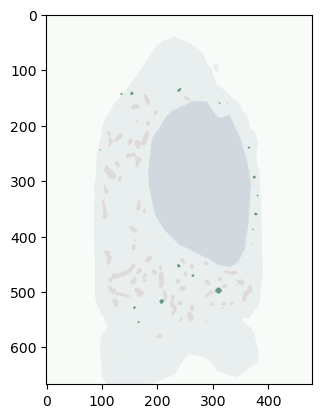

In [318]:
Ves_16_18 = openmrc(NS_1537_16_18_files[3])

slic = 300

plt.imshow(PM_65[slic], cmap='Blues', alpha=0.2)
plt.imshow(Mito_65[slic], cmap='Reds', alpha=0.2)
plt.imshow(Nuc_65[slic], cmap='Blues', alpha=0.2)
plt.imshow(Ves_65[slic], cmap = 'Greens', alpha = 0.5)

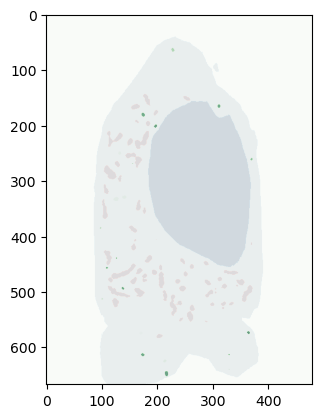

In [319]:
Ves_16_18 = openmrc(NS_1537_16_18_files[3])

slic = 300

plt.imshow(PM_65[slic], cmap='Blues', alpha=0.2)
plt.imshow(Mito_65[slic], cmap='Reds', alpha=0.2)
plt.imshow(Nuc_65[slic], cmap='Blues', alpha=0.2)
plt.imshow(sub_volume_randomplace[slic], cmap = 'Greens', alpha = 0.5)

In [320]:
sub_rando_mitodist = Granule_Mito_Distances(sub_volume_randomplace, Mito_16_18, LACfactordict['1537_16-18'])
sub_rando_mitodist

,Centroid X,Centroid Y,Centroid Z,Group,Min Raw Distance to Mito EDT
0,76.673077,248.673077,238.807692,1,945.927559
1,80.934783,209.260870,236.956522,2,210.021002
2,79.333333,235.888889,219.851852,3,837.400884
3,83.835294,222.317647,212.352941,4,614.146099
4,83.847059,278.313725,223.160784,5,475.336919
...,...,...,...,...,...
674,386.213115,430.639344,205.983607,675,270.027003
675,387.220588,93.397059,202.073529,676,2605.601229
676,389.500000,371.326923,263.250000,677,386.561618
677,393.170213,126.851064,203.340426,678,2177.854119


In [321]:
#rando_mitodist_filtered = rando_mitodist[(rando_mitodist['Min Raw Distance to Mito EDT'] < 50) & (rando_mitodist['Min Raw Distance to Mito EDT'] > 1)]
sub_rando_mitodist_filtered = sub_rando_mitodist[sub_rando_mitodist['Min Raw Distance to Mito EDT'] < 50]
sub_rando_mitodist_filtered

,Centroid X,Centroid Y,Centroid Z,Group,Min Raw Distance to Mito EDT
17,100.349515,405.378641,232.339806,18,42.43065
70,126.975207,581.227273,232.450413,71,30.00300
84,134.834171,291.412060,165.085427,85,42.43065
124,155.510417,446.708333,208.145833,125,30.00300
138,159.343750,393.656250,146.000000,139,42.43065
151,164.258065,518.000000,276.903226,152,42.43065
223,204.901099,536.219780,218.791209,224,42.43065
240,209.894737,196.657895,154.842105,241,30.00300
277,223.782609,322.000000,110.304348,278,42.43065
278,223.816327,323.816327,131.408163,279,30.00300


In [322]:
len(sub_rando_mitodist_filtered)

36

In [323]:
sub_norando_mitodist = Granule_Mito_Distances(Ves_16_18, Mito_16_18, LACfactordict['1537_16-18'])
sub_norando_mitodist

,Centroid X,Centroid Y,Centroid Z,Group,Min Raw Distance to Mito EDT
0,79.469388,280.765306,243.204082,1,666.850008
1,79.204082,218.591837,240.183673,2,450.045005
2,79.902913,241.572816,228.174757,3,806.182349
3,79.956522,256.434783,245.836957,4,711.899821
4,80.081081,298.891892,246.324324,5,381.875849
...,...,...,...,...,...
676,391.319149,338.212766,197.734043,677,539.219945
677,391.918033,407.442623,198.557377,678,347.309838
678,392.951351,420.140541,215.264865,679,513.568640
679,392.333333,254.888889,206.851852,680,470.578672


In [324]:
sub_norando_mitodist_filtered = sub_norando_mitodist[sub_norando_mitodist['Min Raw Distance to Mito EDT'] < 50]
sub_norando_mitodist_filtered

,Centroid X,Centroid Y,Centroid Z,Group,Min Raw Distance to Mito EDT
37,93.221154,415.423077,216.701923,38,30.00300
112,130.255396,204.500000,224.266187,113,30.00300
113,129.500000,475.913043,203.739130,114,30.00300
128,134.682540,442.936508,199.571429,129,30.00300
158,156.470588,121.132353,269.882353,159,30.00300
172,160.931624,381.435897,165.452991,173,30.00300
174,161.474359,331.525641,122.525641,175,30.00300
227,188.847059,558.313725,274.160784,228,30.00300
228,188.250000,367.750000,113.500000,229,30.00300
235,192.333333,368.000000,110.333333,236,30.00300


In [325]:
len(sub_norando_mitodist_filtered)

27

# Testing the Functions

In [806]:
tmpVes = Location_list(NS_1537_19_files[3], NS_1537_19_files[4], 33.33)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [807]:
tmpVes

,X,Y,Z,Group,LAC Value
0,71,263,252,1,0.287995
1,71,263,253,1,0.278924
2,71,264,252,1,0.329832
3,71,264,253,1,0.293704
4,71,265,252,1,0.281009
...,...,...,...,...,...
103211,406,404,245,824,0.343593
103212,406,405,232,823,0.327482
103213,406,405,233,823,0.320443
103214,406,406,232,823,0.352817


In [808]:
PM_1537 = openmrc(NS_1537_19_files[0])
Nuc_1537 = openmrc(NS_1537_19_files[2])
Mito_1537 = openmrc(NS_1537_19_files[1])

placed_df, info = randomize_isg_positions_random_init(
    PM_mask=PM_1537,
    Nuc_mask=Nuc_1537,
    mito_mask=Mito_1537,
    isg_df=tmpVes,
    seed=42,
    proposal_fraction=0.2,
    max_rounds = 200,
    verbose=True,
    randomize_accept_order=True,
    stop_after_no_accept_rounds=20,
    
    pm_log_mu=1.5,
    pm_log_sigma=1.0,
    pm_bin_width=3.0
)

print(info)
print(placed_df.head())

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 824 granules.
Allowed voxels: 20003443

Round 1/200 | unplaced granules: 824
  Trying 165 randomly selected granules this round.
    Proposal progress: 25/165
    Proposal progress: 50/165
    Proposal progress: 75/165
    Proposal progress: 100/165
    Proposal progress: 125/165
    Proposal progress: 150/165
    Proposal progress: 165/165
  Valid proposals this round: 108
  Accepting proposals...
    Acceptance progress: 25/108
    Acceptance progress: 50/108
    Acceptance progress: 75/108
    Acceptance progress: 100/108
    Acceptance progress: 108/108
  Accepted this round: 108
  Remaining unplaced: 716

Round 2/200 | unplaced granules: 716
  Trying 144 randomly selected granules this round.
    Proposal progress: 25/144
    Proposal progress: 50/144
    Proposal progress: 75/144
    Proposal progress: 100/144
    Proposal progress: 125/144
    Proposal prog

In [809]:
placed_df

,X,Y,Z,Group,LAC Value
0,72,413,255,796,0.311810
1,72,413,256,796,0.313197
2,72,413,257,796,0.311886
3,73,412,255,796,0.330466
4,73,412,256,796,0.325946
...,...,...,...,...,...
103211,153,349,106,580,0.294653
103212,153,349,107,580,0.282071
103213,153,350,106,580,0.323612
103214,153,350,107,580,0.311553


In [810]:
placed_df["Group"].nunique()

824

In [811]:
print(info)

{'seed': 42, 'n_granules_total': 824, 'n_granules_placed': 824, 'n_granules_unplaced': 0, 'n_voxels_placed': 103216, 'allowed_voxels': 20003443, 'rounds_used': 55, 'unplaced_ids': [], 'pm_log_mu': 1.5, 'pm_log_sigma': 1.0}


## Image Verification

In [253]:
arr = openmrc(NS_1537_19_files[0])
print(arr.shape)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


(475, 496, 475)


In [599]:
x_max = 475
y_max = 496
z_max = 475

volume_randomplace = np.zeros((z_max, y_max, x_max))

volume_randomplace[placed_df_new["Z"], placed_df_new["Y"], placed_df_new["X"]] = placed_df_new["Group"]

In [122]:
volume_randomplace

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

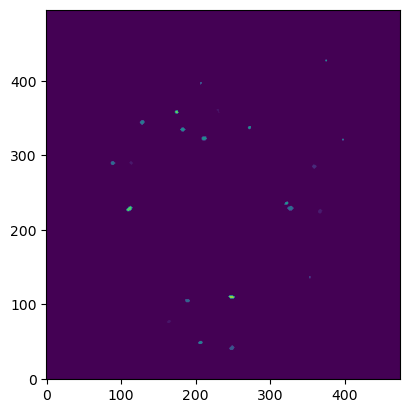

In [375]:
plt.imshow(volume[200], origin='lower')
plt.show()

In [215]:
#Arrays from "Real data"
arr_ves = openmrc(NS_1537_19_files[3])
arr_mito = openmrc(NS_1537_19_files[1])
arr_PM = openmrc(NS_1537_19_files[0])
arr_nuc = openmrc(NS_1537_19_files[2])

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


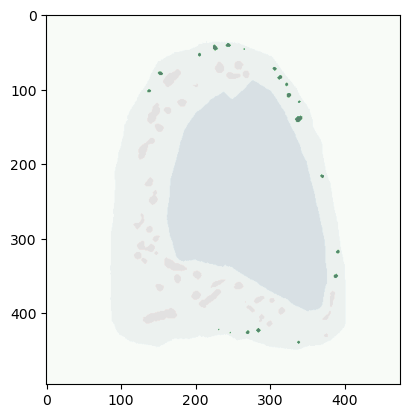

In [495]:
slic = 170

plt.imshow(arr_PM[slic], cmap='Blues', alpha=0.2)
plt.imshow(arr_mito[slic], cmap='Reds', alpha=0.2)
plt.imshow(arr_nuc[slic], cmap='Blues', alpha=0.2)
plt.imshow(arr_ves[slic], cmap = 'Greens', alpha = 0.6)

#plt.savefig("Granules_1537_19.png", dpi=300, bbox_inches='tight')

plt.show()

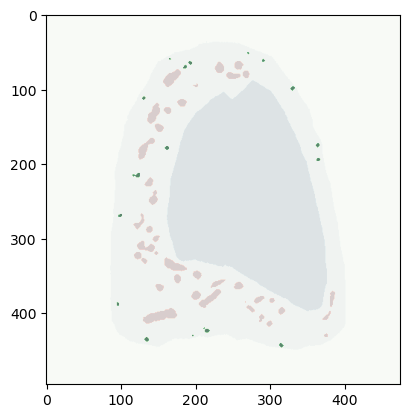

In [600]:
slic = 170

plt.imshow(arr_PM[slic], cmap='Blues', alpha=0.2)
plt.imshow(arr_mito[slic], cmap='Reds', alpha=0.5)
plt.imshow(arr_nuc[slic], cmap='Blues', alpha=0.2)
plt.imshow(volume_randomplace[slic] > 0, cmap = 'Greens', alpha = 0.6)

#plt.savefig("Granules_placedrandom_lognormal.png", dpi=300, bbox_inches='tight')

plt.show()

## MitoDist Calc

In [601]:
Mito_1537_open = openmrc(NS_1537_19_files[1])

rando_mitodist = Granule_Mito_PMDistances(volume_randomplace, arr_PM, Mito_1537_open, LACfactordict['1537_19'])
rando_mitodist

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


,Centroid X,Centroid Y,Centroid Z,Group,Mito Raw Dist EDT,PM Raw Dist EDT
0,72.034722,384.531250,242.131944,1,362.527632,42.430650
1,71.395349,369.953488,259.581395,2,150.015002,67.088748
2,72.567308,329.605769,254.105769,3,230.457418,30.003000
3,75.419355,336.264516,247.219355,4,84.861300,60.006001
4,75.242424,374.883838,214.520202,5,430.624065,67.088748
...,...,...,...,...,...,...
808,401.042857,360.457143,265.000000,809,926.699383,51.966721
809,402.522222,367.177778,242.061111,810,838.475164,30.003000
810,402.048780,334.097561,228.390244,811,943.545466,30.003000
811,402.967213,371.721311,261.049180,812,977.748019,30.003000


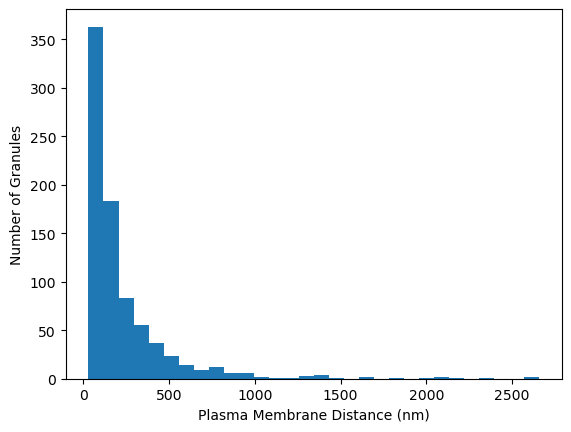

In [602]:
plt.hist(rando_mitodist["PM Raw Dist EDT"],
         bins=30)
plt.xlabel("Plasma Membrane Distance (nm)")
plt.ylabel("Number of Granules")
#plt.savefig("PM_dist_lognormal.png", dpi=300, bbox_inches='tight')
plt.show()

In [603]:
#rando_mitodist_filtered = rando_mitodist[(rando_mitodist['Min Raw Distance to Mito EDT'] < 50) & (rando_mitodist['Min Raw Distance to Mito EDT'] > 1)]
rando_mitodist_filtered = rando_mitodist[rando_mitodist['Mito Raw Dist EDT'] < 50]
rando_mitodist_filtered

,Centroid X,Centroid Y,Centroid Z,Group,Mito Raw Dist EDT,PM Raw Dist EDT
33,87.205882,325.411765,302.955882,34,42.43065,134.177496
48,90.693333,325.826667,220.026667,49,30.00300,510.051005
206,141.165049,238.111650,148.757282,207,30.00300,682.856686
307,173.777778,51.152778,187.541667,308,30.00300,84.861300
363,194.451389,71.076389,153.097222,364,42.43065,339.445199
393,201.841584,383.782178,102.217822,394,30.00300,744.654884
403,208.057377,62.549180,207.508197,404,30.00300,210.021002
423,229.029880,84.964143,137.372510,424,42.43065,314.674122
715,339.981132,144.283019,200.113208,716,30.00300,700.427095
747,354.848485,152.401515,204.166667,748,30.00300,489.334126


In [604]:
len(rando_mitodist_filtered)

10

In [351]:
arr_ves = openmrc(NS_1537_19_files[3])

norando_mitodist = Granule_Mito_PMDistances(arr_ves, arr_PM, Mito_1537_open, LACfactordict['1537_19'])
norando_mitodist

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


,Centroid X,Centroid Y,Centroid Z,Group,Mito Raw Dist EDT,PM Raw Dist EDT
0,73.237500,263.700000,252.012500,1,403.649086,0.000000
1,76.850877,383.903509,215.754386,2,457.975923,134.177496
2,75.581818,384.818182,271.072727,3,182.501126,134.177496
3,78.165049,294.111650,236.757282,4,290.889880,67.088748
4,77.333333,319.015873,244.650794,5,194.441665,120.012001
...,...,...,...,...,...,...
819,398.714286,374.100000,277.442857,820,902.586796,42.430650
820,400.057143,372.114286,266.342857,821,933.474299,67.088748
821,401.348000,400.024000,264.264000,822,537.547941,90.009001
822,403.783019,404.886792,233.028302,823,1092.537741,94.877818


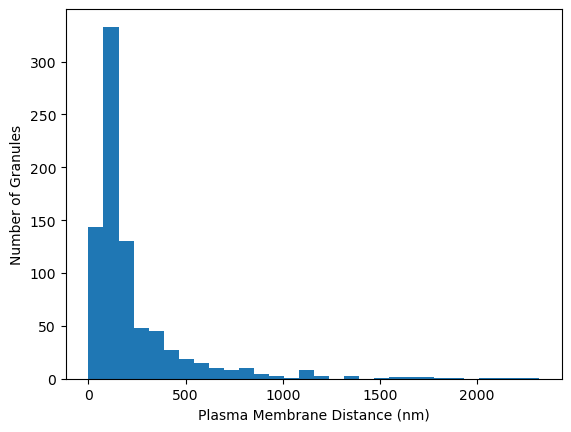

In [356]:
plt.hist(norando_mitodist["PM Raw Dist EDT"],
         bins=30)
plt.xlabel("Plasma Membrane Distance (nm)")
plt.ylabel("Number of Granules")
plt.savefig("PM_dist_1537_19.png", dpi=300, bbox_inches='tight')
plt.show()

In [152]:
norando_mitodist_filtered = norando_mitodist[norando_mitodist['Min Raw Distance to Mito EDT'] < 50]
norando_mitodist_filtered

,Centroid X,Centroid Y,Centroid Z,Group,Min Raw Distance to Mito EDT
11,80.611111,317.833333,226.555556,12,30.00300
15,81.472222,268.750000,228.111111,16,30.00300
73,98.741935,298.387097,208.306452,74,30.00300
108,110.159292,173.884956,207.486726,109,30.00300
314,182.007874,339.440945,158.692913,315,42.43065
402,209.626667,377.080000,400.933333,403,30.00300
468,235.575342,271.356164,393.835616,469,30.00300
496,244.282609,378.771739,407.673913,497,30.00300
696,332.416667,341.351852,250.953704,697,30.00300
722,348.307087,321.771654,195.129921,723,42.43065


In [381]:
len(norando_mitodist_filtered)

12

# Large Scale Functions and Analysis

In [15]:
def run_isg_randomization_pipeline(
    file_list,
    lacfactor,
    seed=123,
    proposal_fraction=0.2,
    max_rounds=200,
    verbose=True,
    randomize_accept_order=True,
    stop_after_no_accept_rounds=20,
    pm_log_mu=1.5,
    pm_log_sigma=1.0,
    pm_bin_width=3.0,
):
    """
    Run the ISG randomization pipeline for one file list.

    Expected file_list order:
        file_list[0] -> PM mask file
        file_list[1] -> Mito mask file
        file_list[2] -> Nuc mask file
        file_list[3] -> Vesicle / ISG location file

    Returns
    -------
    placed_df_new : pd.DataFrame
        Randomized positions converted from xyz to zyx.
    info : dict
        Additional info returned by randomize_isg_positions_random_init.
    """
    # Load vesicle / ISG locations
    tmpVes = Location_list(file_list[3], file_list[4], lacfactor)

    # Load masks
    PM_mask = openmrc(file_list[0])
    Mito_mask = openmrc(file_list[1])
    Nuc_mask = openmrc(file_list[2])

    # Randomize ISG positions
    placed_df, info = randomize_isg_positions_random_init(
        PM_mask=PM_mask,
        Nuc_mask=Nuc_mask,
        mito_mask=Mito_mask,
        isg_df=tmpVes,
        seed=seed,
        proposal_fraction=proposal_fraction,
        max_rounds=max_rounds,
        verbose=verbose,
        randomize_accept_order=randomize_accept_order,
        stop_after_no_accept_rounds=stop_after_no_accept_rounds,
        pm_log_mu=pm_log_mu,
        pm_log_sigma=pm_log_sigma,
        pm_bin_width=pm_bin_width,
    )

    # Convert coordinates
    placed_df_new = xyz_to_zyx(placed_df)

    return placed_df_new, info

In [16]:
def run_mito_distance_pipeline(
    file_list,
    placed_df_new,
    lac_factor,
    mito_dist_threshold=50,
    x_max=None,
    y_max=None,
    z_max=None,
):
    """
    Build a 3D granule volume from randomized coordinates, then compute mito distances
    and return both full and filtered results.

    Expected file_list order:
        file_list[0] -> PM mask file
        file_list[1] -> mito mask file

    Parameters
    ----------
    file_list : list
        List of file paths.
    placed_df_new : pd.DataFrame
        DataFrame with columns ['X', 'Y', 'Z', 'Group'].
    lac_factor : float
        LAC scaling factor, e.g. LACfactordict['1537_19'].
    mito_dist_threshold : float, default=50
        Threshold for filtering 'Mito Raw Dist EDT'.
    x_max, y_max, z_max : int or None
        Shape of the output volume. If any are None, the function uses
        openmrc(file_list[0]).shape as (z_max, y_max, x_max).

    Returns
    -------
    volume_randomplace : np.ndarray
        3D volume created from placed_df_new.
    rando_mitodist : pd.DataFrame
        Full mito distance dataframe.
    rando_mitodist_filtered : pd.DataFrame
        Filtered dataframe.
    """
    # Load PM and mito masks
    arr_PM = openmrc(file_list[0])
    mito_mask = openmrc(file_list[1])

    # Infer shape from PM mask if not provided
    if x_max is None or y_max is None or z_max is None:
        z_max, y_max, x_max = arr_PM.shape

    # Create 3D volume
    volume_randomplace = np.zeros((z_max, y_max, x_max))

    volume_randomplace[
        placed_df_new["Z"].to_numpy(),
        placed_df_new["Y"].to_numpy(),
        placed_df_new["X"].to_numpy()
    ] = placed_df_new["Group"].to_numpy()

    #"New" LAC mrc based on previous one 
    randonew_lac_mrc = np.zeros((z_max, y_max, x_max))
    
    randonew_lac_mrc[
        placed_df_new["Z"].to_numpy(),
        placed_df_new["Y"].to_numpy(),
        placed_df_new["X"].to_numpy()
    ] = placed_df_new["LAC Value"].to_numpy()

    
    # Compute distances
    rando_mitodist = Granule_Mito_PMDistances(
        volume_randomplace,
        arr_PM,
        mito_mask,
        lac_factor,
        randonew_lac_mrc
    )

    # Filter distances
    rando_mitodist_filtered = rando_mitodist[
        rando_mitodist["Mito Raw Dist EDT"] < mito_dist_threshold
    ].copy()

    return volume_randomplace, rando_mitodist, rando_mitodist_filtered

In [17]:
#1537_19 Analysis, seed 123

placed_df_1537_19, info_1537_19 = run_isg_randomization_pipeline(NS_1537_19_files, LACfactordict["1537_19"])

volume_randomplace_1537_19, rando_mitodist_1537_19, rando_mitodist_filtered_1537_19 = run_mito_distance_pipeline(
    file_list=NS_1537_19_files,
    placed_df_new=placed_df_1537_19,
    lac_factor=LACfactordict["1537_19"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 824 granules.
Allowed voxels: 20003443

Round 1/200 | unplaced granules: 824
  Trying 165 randomly selected granules this round.
    Proposal progress: 25/165
    Proposal progress: 50/165
    Proposal progress: 75/165
    Proposal progress: 100/165
    Proposal progress: 125/165
    Proposal progress: 150/165
    Proposal progress: 165/165
  Valid proposals this round: 104
  Accepting proposals...
    Acceptance progress: 25/104
    Acceptance progress: 50/104
    Acceptance progress: 75/104
    Acceptance progress: 100/104
    Acceptance progress: 104/104
  Accepted this round: 104
  Remaining unplaced: 720

Round 2/200 | unplaced granules: 720
  Trying 144 randomly selected granules this round.
    Proposal progress: 25/144
    Proposal progress: 50/144
    Proposal progress: 75/144
    Proposal progress: 100/144
    Proposal progress: 125/144
    Proposal prog

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [18]:
# 7_22, seed 123
placed_df_7_22, info_7_22 = run_isg_randomization_pipeline(NS_7_22_files, LACfactordict["7_22"])

volume_randomplace_7_22, rando_mitodist_7_22, rando_mitodist_filtered_7_22 = run_mito_distance_pipeline(
    file_list=NS_7_22_files,
    placed_df_new=placed_df_7_22,
    lac_factor=LACfactordict["7_22"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 1066 granules.
Allowed voxels: 11982866

Round 1/200 | unplaced granules: 1066
  Trying 214 randomly selected granules this round.
    Proposal progress: 25/214
    Proposal progress: 50/214
    Proposal progress: 75/214
    Proposal progress: 100/214
    Proposal progress: 125/214
    Proposal progress: 150/214
    Proposal progress: 175/214
    Proposal progress: 200/214
    Proposal progress: 214/214
  Valid proposals this round: 128
  Accepting proposals...
    Acceptance progress: 25/128
    Acceptance progress: 50/128
    Acceptance progress: 75/128
    Acceptance progress: 100/128
    Acceptance progress: 125/128
    Acceptance progress: 128/128
  Accepted this round: 127
  Remaining unplaced: 939

Round 2/200 | unplaced granules: 939
  Trying 188 randomly selected granules this round.
    Proposal progress: 25/188
    Proposal progress: 50/188
    Proposal

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [19]:
# 6_5, seed 123
placed_df_6_5, info_6_5 = run_isg_randomization_pipeline(NS_6_5_files, LACfactordict["6_5"])

volume_randomplace_6_5, rando_mitodist_6_5, rando_mitodist_filtered_6_5 = run_mito_distance_pipeline(
    file_list=NS_6_5_files,
    placed_df_new=placed_df_6_5,
    lac_factor=LACfactordict["6_5"]
)


C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 986 granules.
Allowed voxels: 13413090

Round 1/200 | unplaced granules: 986
  Trying 198 randomly selected granules this round.
    Proposal progress: 25/198
    Proposal progress: 50/198
    Proposal progress: 75/198
    Proposal progress: 100/198
    Proposal progress: 125/198
    Proposal progress: 150/198
    Proposal progress: 175/198
    Proposal progress: 198/198
  Valid proposals this round: 132
  Accepting proposals...
    Acceptance progress: 25/132
    Acceptance progress: 50/132
    Acceptance progress: 75/132
    Acceptance progress: 100/132
    Acceptance progress: 125/132
    Acceptance progress: 132/132
  Accepted this round: 129
  Remaining unplaced: 857

Round 2/200 | unplaced granules: 857
  Trying 172 randomly selected granules this round.
    Proposal progress: 25/172
    Proposal progress: 50/172
    Proposal progress: 75/172
    Proposal pr

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [20]:
# 1537_16_18, seed 123
placed_df_1537_16_18, info_1537_16_18 = run_isg_randomization_pipeline(NS_1537_16_18_files, LACfactordict["1537_16-18"])

volume_randomplace_1537_16_18, rando_mitodist_1537_16_18, rando_mitodist_filtered_1537_16_18 = run_mito_distance_pipeline(
    file_list=NS_1537_16_18_files,
    placed_df_new=placed_df_1537_16_18,
    lac_factor=LACfactordict["1537_16-18"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 681 granules.
Allowed voxels: 27427518

Round 1/200 | unplaced granules: 681
  Trying 137 randomly selected granules this round.
    Proposal progress: 25/137
    Proposal progress: 50/137
    Proposal progress: 75/137
    Proposal progress: 100/137
    Proposal progress: 125/137
    Proposal progress: 137/137
  Valid proposals this round: 89
  Accepting proposals...
    Acceptance progress: 25/89
    Acceptance progress: 50/89
    Acceptance progress: 75/89
    Acceptance progress: 89/89
  Accepted this round: 89
  Remaining unplaced: 592

Round 2/200 | unplaced granules: 592
  Trying 119 randomly selected granules this round.
    Proposal progress: 25/119
    Proposal progress: 50/119
    Proposal progress: 75/119
    Proposal progress: 100/119
    Proposal progress: 119/119
  Valid proposals this round: 81
  Accepting proposals...
    Acceptance progress: 25/81

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [21]:
# 7_8_9, seed 123
placed_df_7_8_9, info_7_8_9 = run_isg_randomization_pipeline(NS_7_8_9_files, LACfactordict["7_8=9"])

volume_randomplace_7_8_9, rando_mitodist_7_8_9, rando_mitodist_filtered_7_8_9 = run_mito_distance_pipeline(
    file_list=NS_7_8_9_files,
    placed_df_new=placed_df_7_8_9,
    lac_factor=LACfactordict["7_8=9"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 1039 granules.
Allowed voxels: 25647972

Round 1/200 | unplaced granules: 1039
  Trying 208 randomly selected granules this round.
    Proposal progress: 25/208
    Proposal progress: 50/208
    Proposal progress: 75/208
    Proposal progress: 100/208
    Proposal progress: 125/208
    Proposal progress: 150/208
    Proposal progress: 175/208
    Proposal progress: 200/208
    Proposal progress: 208/208
  Valid proposals this round: 140
  Accepting proposals...
    Acceptance progress: 25/140
    Acceptance progress: 50/140
    Acceptance progress: 75/140
    Acceptance progress: 100/140
    Acceptance progress: 125/140
    Acceptance progress: 140/140
  Accepted this round: 138
  Remaining unplaced: 901

Round 2/200 | unplaced granules: 901
  Trying 181 randomly selected granules this round.
    Proposal progress: 25/181
    Proposal progress: 50/181
    Proposal

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [22]:
# 6_17_19, seed 123
placed_df_6_17_19, info_6_17_19 = run_isg_randomization_pipeline(NS_6_17_19_files, LACfactordict["6_17-19"])

volume_randomplace_6_17_19, rando_mitodist_6_17_19, rando_mitodist_filtered_6_17_19 = run_mito_distance_pipeline(
    file_list=NS_6_17_19_files,
    placed_df_new=placed_df_6_17_19,
    lac_factor=LACfactordict["6_17-19"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 1377 granules.
Allowed voxels: 19302912

Round 1/200 | unplaced granules: 1377
  Trying 276 randomly selected granules this round.
    Proposal progress: 25/276
    Proposal progress: 50/276
    Proposal progress: 75/276
    Proposal progress: 100/276
    Proposal progress: 125/276
    Proposal progress: 150/276
    Proposal progress: 175/276
    Proposal progress: 200/276
    Proposal progress: 225/276
    Proposal progress: 250/276
    Proposal progress: 275/276
    Proposal progress: 276/276
  Valid proposals this round: 190
  Accepting proposals...
    Acceptance progress: 25/190
    Acceptance progress: 50/190
    Acceptance progress: 75/190
    Acceptance progress: 100/190
    Acceptance progress: 125/190
    Acceptance progress: 150/190
    Acceptance progress: 175/190
    Acceptance progress: 190/190
  Accepted this round: 188
  Remaining unplaced: 1189

R

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [832]:
(len(rando_mitodist_filtered_1537_19)/820)*100

1.5853658536585367

In [614]:
(len(rando_mitodist_filtered_6_17_19)/1346)*100

1.8573551263001487

In [615]:
(len(rando_mitodist_filtered_7_8_9)/1036)*100

1.3513513513513513

In [616]:
(len(rando_mitodist_filtered_1537_16_18)/679)*100

3.0927835051546393

In [617]:
(len(rando_mitodist_filtered_6_5)/1011)*100

0.791295746785361

In [618]:
(len(rando_mitodist_filtered_7_22)/1059)*100

3.9660056657223794

In [560]:
rando_contact_42 = [1.22, 2.15, 1.35, 2.94, 1.08, 3.21]
#seed = 42

In [561]:
exp_contact = [2.36, 7.22, 3.98, 1.93, 2.23, 1.46]

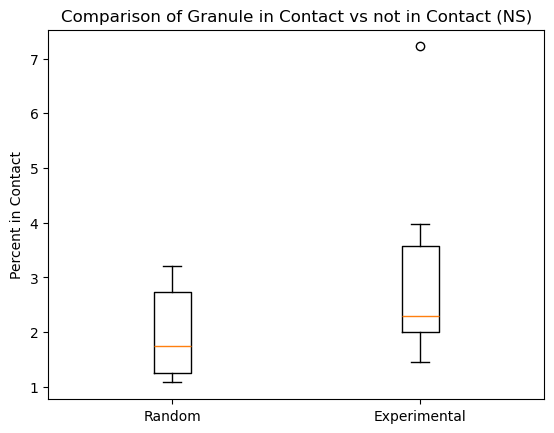

In [679]:
import matplotlib.pyplot as plt

plt.boxplot(
    [rando_contact_42, exp_contact],
    labels=["Random", "Experimental"]
)

plt.ylabel("Percent in Contact")
plt.title("Comparison of Granule in Contact vs not in Contact (NS)")

#plt.savefig("Contact_boxplot_NS.png", dpi=300, bbox_inches='tight')

plt.show()

# Glucose, TAK, EXT Analysis

In [838]:
# Glu 9905 7
placed_df_9905_7, info_9905_7 = run_isg_randomization_pipeline(
    Glu_9905_7_files,
    LACfactordict["9905_7"]
)
volume_randomplace_9905_7, rando_mitodist_9905_7, rando_mitodist_filtered_9905_7 = run_mito_distance_pipeline(
    file_list=Glu_9905_7_files,
    placed_df_new=placed_df_9905_7,
    lac_factor=LACfactordict["9905_7"]
)


# Glu 9905 8
placed_df_9905_8, info_9905_8 = run_isg_randomization_pipeline(
    Glu_9905_8_files,
    LACfactordict["9905_8"]
)
volume_randomplace_9905_8, rando_mitodist_9905_8, rando_mitodist_filtered_9905_8 = run_mito_distance_pipeline(
    file_list=Glu_9905_8_files,
    placed_df_new=placed_df_9905_8,
    lac_factor=LACfactordict["9905_8"]
)


# Glu 9905 11_12
placed_df_9905_11_12, info_9905_11_12 = run_isg_randomization_pipeline(
    Glu_9905_11_12_files,
    LACfactordict["9905_11-12"]
)
volume_randomplace_9905_11_12, rando_mitodist_9905_11_12, rando_mitodist_filtered_9905_11_12 = run_mito_distance_pipeline(
    file_list=Glu_9905_11_12_files,
    placed_df_new=placed_df_9905_11_12,
    lac_factor=LACfactordict["9905_11-12"]
)


# Glu 9905 8_9
placed_df_9905_8_9, info_9905_8_9 = run_isg_randomization_pipeline(
    Glu_9905_8_9_files,
    LACfactordict["9905_8"]
)
volume_randomplace_9905_8_9, rando_mitodist_9905_8_9, rando_mitodist_filtered_9905_8_9 = run_mito_distance_pipeline(
    file_list=Glu_9905_8_9_files,
    placed_df_new=placed_df_9905_8_9,
    lac_factor=LACfactordict["9905_8"]
)


# Glu 9908 4_5
placed_df_9908_4_5, info_9908_4_5 = run_isg_randomization_pipeline(
    Glu_9908_4_5_files,
    LACfactordict["9908_4-5"]
)
volume_randomplace_9908_4_5, rando_mitodist_9908_4_5, rando_mitodist_filtered_9908_4_5 = run_mito_distance_pipeline(
    file_list=Glu_9908_4_5_files,
    placed_df_new=placed_df_9908_4_5,
    lac_factor=LACfactordict["9908_4-5"]
)


# Glu 9905 12_13
placed_df_9905_12_13, info_9905_12_13 = run_isg_randomization_pipeline(
    Glu_9905_12_13_files,
    LACfactordict["9905_12-13"]
)
volume_randomplace_9905_12_13, rando_mitodist_9905_12_13, rando_mitodist_filtered_9905_12_13 = run_mito_distance_pipeline(
    file_list=Glu_9905_12_13_files,
    placed_df_new=placed_df_9905_12_13,
    lac_factor=LACfactordict["9905_12-13"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 833 granules.
Allowed voxels: 9893862

Round 1/200 | unplaced granules: 833
  Trying 167 randomly selected granules this round.
    Proposal progress: 25/167
    Proposal progress: 50/167
    Proposal progress: 75/167
    Proposal progress: 100/167
    Proposal progress: 125/167
    Proposal progress: 150/167
    Proposal progress: 167/167
  Valid proposals this round: 129
  Accepting proposals...
    Acceptance progress: 25/129
    Acceptance progress: 50/129
    Acceptance progress: 75/129
    Acceptance progress: 100/129
    Acceptance progress: 125/129
    Acceptance progress: 129/129
  Accepted this round: 129
  Remaining unplaced: 704

Round 2/200 | unplaced granules: 704
  Trying 141 randomly selected granules this round.
    Proposal progress: 25/141
    Proposal progress: 50/141
    Proposal progress: 75/141
    Proposal progress: 100/141
    Proposal pro

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 1051 granules.
Allowed voxels: 27958093

Round 1/200 | unplaced granules: 1051
  Trying 211 randomly selected granules this round.
    Proposal progress: 25/211
    Proposal progress: 50/211
    Proposal progress: 75/211
    Proposal progress: 100/211
    Proposal progress: 125/211
    Proposal progress: 150/211
    Proposal progress: 175/211
    Proposal progress: 200/211
    Proposal progress: 211/211
  Valid proposals this round: 134
  Accepting proposals...
    Acceptance progress: 25/134
    Acceptance progress: 50/134
    Acceptance progress: 75/134
    Acceptance progress: 100/134
    Acceptance progress: 125/134
    Acceptance progress: 134/134
  Accepted this round: 134
  Remaining unplaced: 917

Round 2/200 | unplaced granules: 917
  Trying 184 randomly selected granules this round.
    Proposal progress: 25/184
    Proposal progress: 50/184
    Proposal

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


...

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 885 granules.
Allowed voxels: 8223422

Round 1/200 | unplaced granules: 885
  Trying 177 randomly selected granules this round.
    Proposal progress: 25/177
    Proposal progress: 50/177
    Proposal progress: 75/177
    Proposal progress: 100/177
    Proposal progress: 125/177
    Proposal progress: 150/177
    Proposal progress: 175/177
    Proposal progress: 177/177
  Valid proposals this round: 103
  Accepting proposals...
    Acceptance progress: 25/103
    Acceptance progress: 50/103
    Acceptance progress: 75/103
    Acceptance progress: 100/103
    Acceptance progress: 103/103
  Accepted this round: 103
  Remaining unplaced: 782

Round 2/200 | unplaced granules: 782
  Trying 157 randomly selected granules this round.
    Proposal progress: 25/157
    Proposal progress: 50/157
    Proposal progress: 75/157
    Proposal progress: 100/157
    Proposal progr

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 517 granules.
Allowed voxels: 10933058

Round 1/200 | unplaced granules: 517
  Trying 104 randomly selected granules this round.
    Proposal progress: 25/104
    Proposal progress: 50/104
    Proposal progress: 75/104
    Proposal progress: 100/104
    Proposal progress: 104/104
  Valid proposals this round: 79
  Accepting proposals...
    Acceptance progress: 25/79
    Acceptance progress: 50/79
    Acceptance progress: 75/79
    Acceptance progress: 79/79
  Accepted this round: 79
  Remaining unplaced: 438

Round 2/200 | unplaced granules: 438
  Trying 88 randomly selected granules this round.
    Proposal progress: 25/88
    Proposal progress: 50/88
    Proposal progress: 75/88
    Proposal progress: 88/88
  Valid proposals this round: 51
  Accepting proposals...
    Acceptance progress: 25/51
    Acceptance progress: 50/51
    Acceptance progress: 51/51
  Acc

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [692]:
#(len(rando_mitodist_filtered_9905_12_13)/515)*100
#(len(rando_mitodist_filtered_9908_4_5)/863)*100  #much higher?
#(len(rando_mitodist_filtered_9905_8_9)/927)*100
#(len(rando_mitodist_filtered_9905_11_12)/1047)*100
#(len(rando_mitodist_filtered_9905_8)/1046)*100
(len(rando_mitodist_filtered_9905_7)/830)*100

#av = 3.44 (w/o 2nd, is 2.44)

1.8072289156626504

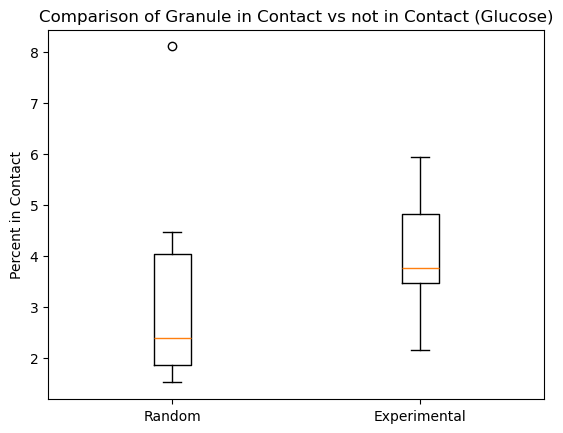

In [694]:
glu_rando_contact = [4.46, 8.11, 1.51, 2.00, 2.77, 1.80]
glu_exp_contact = [2.14, 5.10, 5.93, 3.53, 3.44, 3.98]

plt.boxplot(
    [glu_rando_contact, glu_exp_contact],
    labels=["Random", "Experimental"]
)

plt.ylabel("Percent in Contact")
plt.title("Comparison of Granule in Contact vs not in Contact (Glucose)")

#plt.savefig("Contact_boxplot_Glu.png", dpi=300, bbox_inches='tight')

plt.show()

In [839]:
# TAK 9920 8_9
placed_df_9920_8_9, info_9920_8_9 = run_isg_randomization_pipeline(
    TAK_9920_8_9_files,
    LACfactordict["9919_8-9"]
)
volume_randomplace_9920_8_9, rando_mitodist_9920_8_9, rando_mitodist_filtered_9920_8_9 = run_mito_distance_pipeline(
    file_list=TAK_9920_8_9_files,
    placed_df_new=placed_df_9920_8_9,
    lac_factor=LACfactordict["9919_8-9"]
)


# TAK 9919 12_13
placed_df_9919_12_13, info_9919_12_13 = run_isg_randomization_pipeline(
    TAK_9919_12_13_files,
    LACfactordict["9919_12-13"]
)
volume_randomplace_9919_12_13, rando_mitodist_9919_12_13, rando_mitodist_filtered_9919_12_13 = run_mito_distance_pipeline(
    file_list=TAK_9919_12_13_files,
    placed_df_new=placed_df_9919_12_13,
    lac_factor=LACfactordict["9919_12-13"]
)


# TAK 9917 2
placed_df_9917_2, info_9917_2 = run_isg_randomization_pipeline(
    TAK_9917_2_files,
    LACfactordict["9917_2"]
)
volume_randomplace_9917_2, rando_mitodist_9917_2, rando_mitodist_filtered_9917_2 = run_mito_distance_pipeline(
    file_list=TAK_9917_2_files,
    placed_df_new=placed_df_9917_2,
    lac_factor=LACfactordict["9917_2"]
)


# TAK 9917 1
placed_df_9917_1, info_9917_1 = run_isg_randomization_pipeline(
    TAK_9917_1_files,
    LACfactordict["9917_1"]
)
volume_randomplace_9917_1, rando_mitodist_9917_1, rando_mitodist_filtered_9917_1 = run_mito_distance_pipeline(
    file_list=TAK_9917_1_files,
    placed_df_new=placed_df_9917_1,
    lac_factor=LACfactordict["9917_1"]
)


# TAK 2213 4
placed_df_2213_4, info_2213_4 = run_isg_randomization_pipeline(
    TAK_2213_4_files,
    LACfactordict["2213_11-12"]
)
volume_randomplace_2213_4, rando_mitodist_2213_4, rando_mitodist_filtered_2213_4 = run_mito_distance_pipeline(
    file_list=TAK_2213_4_files,
    placed_df_new=placed_df_2213_4,
    lac_factor=LACfactordict["2213_11-12"]
)


# TAK 2213 11_12
placed_df_2213_11_12, info_2213_11_12 = run_isg_randomization_pipeline(
    TAK_2213_11_12_files,
    LACfactordict["2213_11-12"]
)
volume_randomplace_2213_11_12, rando_mitodist_2213_11_12, rando_mitodist_filtered_2213_11_12 = run_mito_distance_pipeline(
    file_list=TAK_2213_11_12_files,
    placed_df_new=placed_df_2213_11_12,
    lac_factor=LACfactordict["2213_11-12"]
)


# TAK 2211 9_11
placed_df_2211_9_11, info_2211_9_11 = run_isg_randomization_pipeline(
    TAK_2211_9_11_files,
    LACfactordict["2211_9-11"]
)
volume_randomplace_2211_9_11, rando_mitodist_2211_9_11, rando_mitodist_filtered_2211_9_11 = run_mito_distance_pipeline(
    file_list=TAK_2211_9_11_files,
    placed_df_new=placed_df_2211_9_11,
    lac_factor=LACfactordict["2211_9-11"]
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 1323 granules.
Allowed voxels: 19898100

Round 1/200 | unplaced granules: 1323
  Trying 265 randomly selected granules this round.
    Proposal progress: 25/265
    Proposal progress: 50/265
    Proposal progress: 75/265
    Proposal progress: 100/265
    Proposal progress: 125/265
    Proposal progress: 150/265
    Proposal progress: 175/265
    Proposal progress: 200/265
    Proposal progress: 225/265
    Proposal progress: 250/265
    Proposal progress: 265/265
  Valid proposals this round: 179
  Accepting proposals...
    Acceptance progress: 25/179
    Acceptance progress: 50/179
    Acceptance progress: 75/179
    Acceptance progress: 100/179
    Acceptance progress: 125/179
    Acceptance progress: 150/179
    Acceptance progress: 175/179
    Acceptance progress: 179/179
  Accepted this round: 179
  Remaining unplaced: 1144

Round 2/200 | unplaced granules:

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 937 granules.
Allowed voxels: 9610769

Round 1/200 | unplaced granules: 937
  Trying 188 randomly selected granules this round.
    Proposal progress: 25/188
    Proposal progress: 50/188
    Proposal progress: 75/188
    Proposal progress: 100/188
    Proposal progress: 125/188
    Proposal progress: 150/188
    Proposal progress: 175/188
    Proposal progress: 188/188
  Valid proposals this round: 98
  Accepting proposals...
    Acceptance progress: 25/98
    Acceptance progress: 50/98
    Acceptance progress: 75/98
    Acceptance progress: 98/98
  Accepted this round: 98
  Remaining unplaced: 839

Round 2/200 | unplaced granules: 839
  Trying 168 randomly selected granules this round.
    Proposal progress: 25/168
    Proposal progress: 50/168
    Proposal progress: 75/168
    Proposal progress: 100/168
    Proposal progress: 125/168
    Proposal progress: 150/

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


...

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 357 granules.
Allowed voxels: 25679425

Round 1/200 | unplaced granules: 357
  Trying 72 randomly selected granules this round.
    Proposal progress: 25/72
    Proposal progress: 50/72
    Proposal progress: 72/72
  Valid proposals this round: 43
  Accepting proposals...
    Acceptance progress: 25/43
    Acceptance progress: 43/43
  Accepted this round: 43
  Remaining unplaced: 314

Round 2/200 | unplaced granules: 314
  Trying 63 randomly selected granules this round.
    Proposal progress: 25/63
    Proposal progress: 50/63
    Proposal progress: 63/63
  Valid proposals this round: 42
  Accepting proposals...
    Acceptance progress: 25/42
    Acceptance progress: 42/42
  Accepted this round: 42
  Remaining unplaced: 272

Round 3/200 | unplaced granules: 272
  Trying 55 randomly selected granules this round.
    Proposal progress: 25/55
    Proposal progress: 

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 421 granules.
Allowed voxels: 11446585

Round 1/200 | unplaced granules: 421
  Trying 85 randomly selected granules this round.
    Proposal progress: 25/85
    Proposal progress: 50/85
    Proposal progress: 75/85
    Proposal progress: 85/85
  Valid proposals this round: 55
  Accepting proposals...
    Acceptance progress: 25/55
    Acceptance progress: 50/55
    Acceptance progress: 55/55
  Accepted this round: 55
  Remaining unplaced: 366

Round 2/200 | unplaced granules: 366
  Trying 74 randomly selected granules this round.
    Proposal progress: 25/74
    Proposal progress: 50/74
    Proposal progress: 74/74
  Valid proposals this round: 45
  Accepting proposals...
    Acceptance progress: 25/45
    Acceptance progress: 45/45
  Accepted this round: 45
  Remaining unplaced: 321

Round 3/200 | unplaced granules: 321
  Trying 65 randomly selected granules this

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


In [703]:
rando_mitodist_filtered_2211_9_11

,Centroid X,Centroid Y,Centroid Z,Group,Mito Raw Dist EDT,PM Raw Dist EDT
8,102.817975,336.616610,222.246871,9,30.00300,90.009001
19,112.066482,327.903047,247.398892,20,30.00300,254.583900
82,143.597561,486.536585,152.963415,83,30.00300,230.457418
159,196.602588,526.449168,292.756007,160,30.00300,155.900163
261,262.593750,565.656250,269.656250,262,42.43065,60.006001
267,265.970000,538.770000,106.060000,268,30.00300,417.893438
330,311.129630,565.851852,331.925926,331,42.43065,301.526421
337,317.789474,487.500000,344.631579,338,42.43065,403.649086
350,328.456954,486.019868,138.079470,351,42.43065,256.345747
354,329.445946,552.810811,153.445946,355,30.00300,230.457418


In [700]:
#(len(rando_mitodist_filtered_2211_9_11)/417)*100
#(len(rando_mitodist_filtered_2213_11_12)/353)*100
#(len(rando_mitodist_filtered_2213_4)/616)*100
#(len(rando_mitodist_filtered_9917_1)/1450)*100
#(len(rando_mitodist_filtered_9917_2)/520)*100
#(len(rando_mitodist_filtered_9919_12_13)/930)*100
(len(rando_mitodist_filtered_9920_8_9)/1315)*100

#av of 4.01% in contact

3.574144486692015

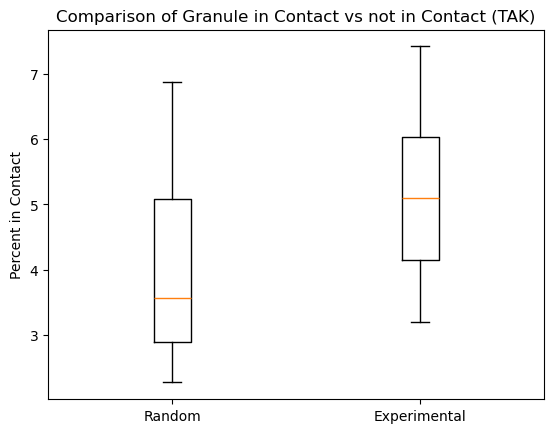

In [702]:
tak_rando_contact = [3.57, 6.88, 4.80, 5.37, 2.27, 3.39, 2.39]
tak_exp_contact = [4.56, 5.10, 3.73, 5.93, 6.15, 7.42, 3.19]

plt.boxplot(
    [tak_rando_contact, tak_exp_contact],
    labels=["Random", "Experimental"]
)

plt.ylabel("Percent in Contact")
plt.title("Comparison of Granule in Contact vs not in Contact (TAK)")

#plt.savefig("Contact_boxplot_TAK.png", dpi=300, bbox_inches='tight')

plt.show()

In [840]:
# EXT 9913 1_2
placed_df_9913_1_2, info_9913_1_2 = run_isg_randomization_pipeline(
    Ext_9913_1_2_files,
    LACfactordict["9913_1-2"]
)
volume_randomplace_9913_1_2, rando_mitodist_9913_1_2, rando_mitodist_filtered_9913_1_2 = run_mito_distance_pipeline(
    file_list=Ext_9913_1_2_files,
    placed_df_new=placed_df_9913_1_2,
    lac_factor=LACfactordict["9913_1-2"]
)


# EXT 9913 5_6
placed_df_9913_5_6, info_9913_5_6 = run_isg_randomization_pipeline(
    Ext_9913_5_6_files,
    LACfactordict["9913_5-6"]
)
volume_randomplace_9913_5_6, rando_mitodist_9913_5_6, rando_mitodist_filtered_9913_5_6 = run_mito_distance_pipeline(
    file_list=Ext_9913_5_6_files,
    placed_df_new=placed_df_9913_5_6,
    lac_factor=LACfactordict["9913_5-6"]
)


# EXT 9913 3_4
placed_df_9913_3_4, info_9913_3_4 = run_isg_randomization_pipeline(
    Ext_9913_3_4_files,
    LACfactordict["9913_3-4"]
)
volume_randomplace_9913_3_4, rando_mitodist_9913_3_4, rando_mitodist_filtered_9913_3_4 = run_mito_distance_pipeline(
    file_list=Ext_9913_3_4_files,
    placed_df_new=placed_df_9913_3_4,
    lac_factor=LACfactordict["9913_3-4"]
)


# EXT 9911 2
placed_df_9911_2, info_9911_2 = run_isg_randomization_pipeline(
    Ext_9911_2_files,
    LACfactordict["9911_2"]
)
volume_randomplace_9911_2, rando_mitodist_9911_2, rando_mitodist_filtered_9911_2 = run_mito_distance_pipeline(
    file_list=Ext_9911_2_files,
    placed_df_new=placed_df_9911_2,
    lac_factor=LACfactordict["9911_2"]
)


# EXT 9910 4
placed_df_9910_4, info_9910_4 = run_isg_randomization_pipeline(
    Ext_9910_4_files,
    LACfactordict["9910_4"]
)
volume_randomplace_9910_4, rando_mitodist_9910_4, rando_mitodist_filtered_9910_4 = run_mito_distance_pipeline(
    file_list=Ext_9910_4_files,
    placed_df_new=placed_df_9910_4,
    lac_factor=LACfactordict["9910_4"]
)

Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 697 granules.
Allowed voxels: 18185177

Round 1/200 | unplaced granules: 697
  Trying 140 randomly selected granules this round.
    Proposal progress: 25/140
    Proposal progress: 50/140
    Proposal progress: 75/140
    Proposal progress: 100/140
    Proposal progress: 125/140
    Proposal progress: 140/140
  Valid proposals this round: 93
  Accepting proposals...
    Acceptance progress: 25/93
    Acceptance progress: 50/93
    Acceptance progress: 75/93
    Acceptance progress: 93/93
  Accepted this round: 93
  Remaining unplaced: 604

Round 2/200 | unplaced granules: 604
  Trying 121 randomly selected granules this round.
    Proposal progress: 25/121
    Proposal progress: 50/121
    Proposal progress: 75/121
    Proposal progress: 100/121
    Proposal progress: 121/121
  Valid proposals this round: 77
  Accepting proposals...
    Acceptance progress: 25/77

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 364 granules.
Allowed voxels: 8004207

Round 1/200 | unplaced granules: 364
  Trying 73 randomly selected granules this round.
    Proposal progress: 25/73
    Proposal progress: 50/73
    Proposal progress: 73/73
  Valid proposals this round: 54
  Accepting proposals...
    Acceptance progress: 25/54
    Acceptance progress: 50/54
    Acceptance progress: 54/54
  Accepted this round: 54
  Remaining unplaced: 310

Round 2/200 | unplaced granules: 310
  Trying 62 randomly selected granules this round.
    Proposal progress: 25/62
    Proposal progress: 50/62
    Proposal progress: 62/62
  Valid proposals this round: 31
  Accepting proposals...
    Acceptance progress: 25/31
    Acceptance progress: 31/31
  Accepted this round: 31
  Remaining unplaced: 279

Round 3/200 | unplaced granules: 279
  Trying 56 randomly selected granules this round.
    Proposal progress:

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Building allowed-space mask...
Building granule library...
Computing PM distance bins...
Starting random initialization for 379 granules.
Allowed voxels: 9362452

Round 1/200 | unplaced granules: 379
  Trying 76 randomly selected granules this round.
    Proposal progress: 25/76
    Proposal progress: 50/76
    Proposal progress: 75/76
    Proposal progress: 76/76
  Valid proposals this round: 61
  Accepting proposals...
    Acceptance progress: 25/61
    Acceptance progress: 50/61
    Acceptance progress: 61/61
  Accepted this round: 61
  Remaining unplaced: 318

Round 2/200 | unplaced granules: 318
  Trying 64 randomly selected granules this round.
    Proposal progress: 25/64
    Proposal progress: 50/64
    Proposal progress: 64/64
  Valid proposals this round: 47
  Accepting proposals...
    Acceptance progress: 25/47
    Acceptance progress: 47/47
  Accepted this round: 47
  Remaining unplaced: 271

Round 3/200 | unplaced granules: 271
  Trying 55 randomly selected granules this 

In [676]:
#(len(rando_mitodist_filtered_9910_4)/374)*100
#(len(rando_mitodist_filtered_9911_2)/364)*100
#(len(rando_mitodist_filtered_9913_3_4)/1086)*100
#(len(rando_mitodist_filtered_9913_5_6)/853)*100
(len(rando_mitodist_filtered_9913_1_2)/853)*100

#Av = 3.554

1.992966002344666

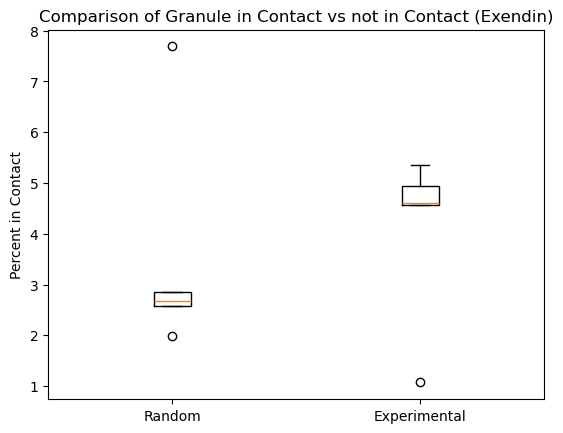

In [681]:
ex_rando_contact = [2.67, 7.69, 2.85, 2.58, 1.99]
ex_exp_contact = [1.07, 4.95, 4.60, 4.57, 5.35]

plt.boxplot(
    [ex_rando_contact, ex_exp_contact],
    labels=["Random", "Experimental"]
)

plt.ylabel("Percent in Contact")
plt.title("Comparison of Granule in Contact vs not in Contact (Exendin)")

#plt.savefig("Contact_boxplot_Ex.png", dpi=300, bbox_inches='tight')

plt.show()

# LAC, Diameter, etc. of Granules in Contact

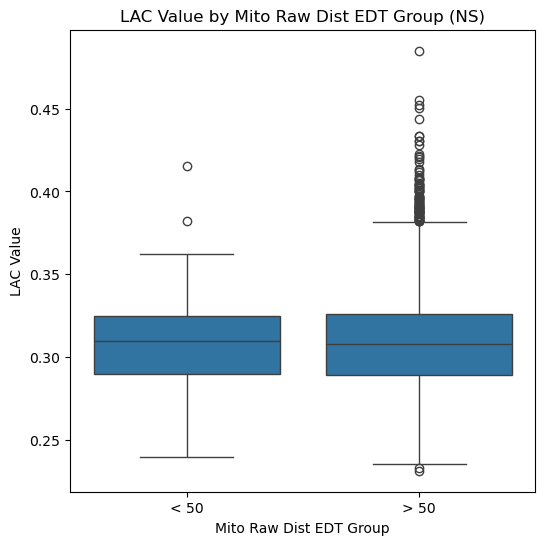

In [904]:
#NS
rando_mitodist_ns_concat = pd.concat(
    [
        rando_mitodist_1537_19.assign(Cell="1537_19"),
        rando_mitodist_7_22.assign(Cell="7_22"),
        rando_mitodist_6_5.assign(Cell="6_5"),
        rando_mitodist_1537_16_18.assign(Cell="1537_16_18"),
        rando_mitodist_7_8_9.assign(Cell="7_8_9"),
        rando_mitodist_6_17_19.assign(Cell="6_17_19"),
    ],
    ignore_index=True
)
#rando_mitodist_ns_concat.to_csv("rando_mitodist_ns_concat.csv", index=False)


# Create distance groups
rando_mitodist_ns_concat["Distance_Group"] = pd.cut(
    rando_mitodist_ns_concat["Mito Raw Dist EDT"],
    bins=[-float("inf"), 50, float("inf")],
    labels=["< 50", "> 50"]
)
# Make boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=rando_mitodist_ns_concat,
    x="Distance_Group",
    y="LAC Value"
)
plt.xlabel("Mito Raw Dist EDT Group")
plt.ylabel("LAC Value")
plt.title("LAC Value by Mito Raw Dist EDT Group (NS)")

#Save plot
#plt.savefig("LAC_vs_MitoDist_NS_Boxplot.png",dpi=300,bbox_inches="tight")


plt.show()

In [882]:
# Extract groups
group_lt_50 = rando_mitodist_ns_concat.loc[
    rando_mitodist_ns_concat["Distance_Group"] == "< 50",
    "LAC Value"
].dropna()

group_gt_50 = rando_mitodist_ns_concat.loc[
    rando_mitodist_ns_concat["Distance_Group"] == "> 50",
    "LAC Value"
].dropna()

# Welch's t-test
t_stat, p_value = ttest_ind(
    group_lt_50,
    group_gt_50,
    equal_var=False
)

print("Welch's t-test results")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Welch's t-test results
T-statistic: -0.39791985396920726
P-value: 0.6913529969971257


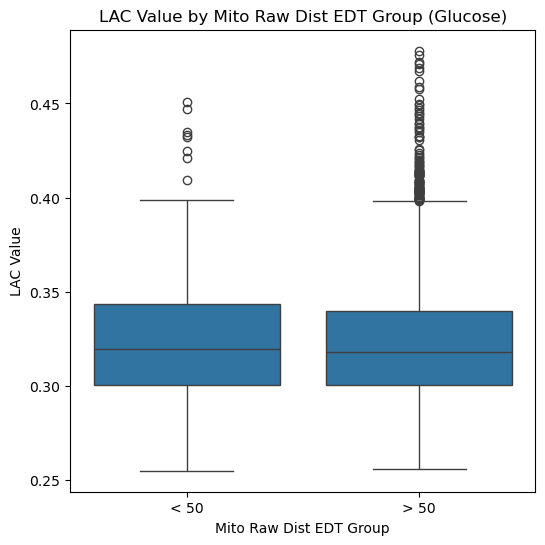

In [902]:
#Glucose
rando_mitodist_glu_concat = pd.concat(
    [
        rando_mitodist_9905_7.assign(Cell="9905_7"),
        rando_mitodist_9905_8.assign(Cell="9905_8"),
        rando_mitodist_9905_11_12.assign(Cell="9905_11_12"),
        rando_mitodist_9905_8_9.assign(Cell="9905_8_9"),
        rando_mitodist_9908_4_5.assign(Cell="9908_4_5"),
        rando_mitodist_9905_12_13.assign(Cell="9905_12_13"),
    ],
    ignore_index=True
)
#rando_mitodist_glu_concat.to_csv("rando_mitodist_glu_concat.csv", index=False)


# Create distance groups
rando_mitodist_glu_concat["Distance_Group"] = pd.cut(
    rando_mitodist_glu_concat["Mito Raw Dist EDT"],
    bins=[-float("inf"), 50, float("inf")],
    labels=["< 50", "> 50"]
)
# Make boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=rando_mitodist_glu_concat,
    x="Distance_Group",
    y="LAC Value"
)
plt.xlabel("Mito Raw Dist EDT Group")
plt.ylabel("LAC Value")
plt.title("LAC Value by Mito Raw Dist EDT Group (Glucose)")

# Save plot
#plt.savefig("LAC_vs_MitoDist_Glucose_Boxplot.png",dpi=300,bbox_inches="tight")

plt.show()

In [872]:
# Extract groups
glugroup_lt_50 = rando_mitodist_glu_concat.loc[
    rando_mitodist_glu_concat["Distance_Group"] == "< 50",
    "LAC Value"
].dropna()

glugroup_gt_50 = rando_mitodist_glu_concat.loc[
    rando_mitodist_glu_concat["Distance_Group"] == "> 50",
    "LAC Value"
].dropna()

# Welch's t-test
t_stat, p_value = ttest_ind(
    glugroup_lt_50,
    glugroup_gt_50,
    equal_var=False
)

print("Welch's t-test results")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Welch's t-test results
T-statistic: 1.539687528734378
P-value: 0.12540020764455004


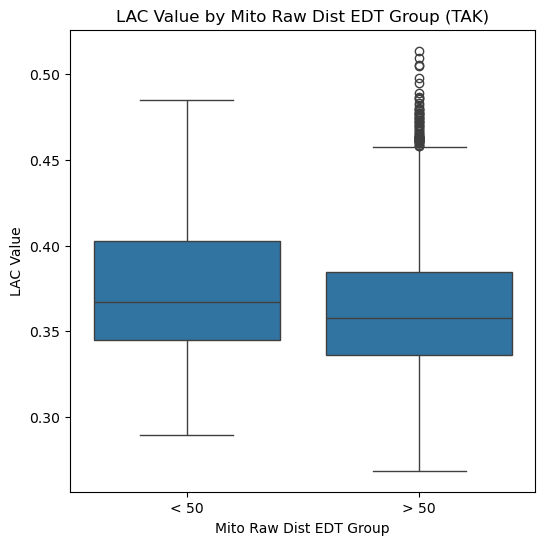

In [906]:
#TAK
rando_mitodist_TAK_concat = pd.concat(
    [
        rando_mitodist_9920_8_9.assign(Cell="9920_8_9"),
        rando_mitodist_9919_12_13.assign(Cell="9919_12_13"),
        rando_mitodist_9917_2.assign(Cell="9917_2"),
        rando_mitodist_9917_1.assign(Cell="9917_1"),
        rando_mitodist_2213_4.assign(Cell="2213_4"),
        rando_mitodist_2213_11_12.assign(Cell="2213_11_12"),
        rando_mitodist_2211_9_11.assign(Cell="2211_9_11"),
    ],
    ignore_index=True
)
#rando_mitodist_TAK_concat.to_csv("rando_mitodist_TAK_concat.csv", index=False)


# Create distance groups
rando_mitodist_TAK_concat["Distance_Group"] = pd.cut(
    rando_mitodist_TAK_concat["Mito Raw Dist EDT"],
    bins=[-float("inf"), 50, float("inf")],
    labels=["< 50", "> 50"]
)
# Make boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=rando_mitodist_TAK_concat,
    x="Distance_Group",
    y="LAC Value"
)
plt.xlabel("Mito Raw Dist EDT Group")
plt.ylabel("LAC Value")
plt.title("LAC Value by Mito Raw Dist EDT Group (TAK)")

#saveplot
#plt.savefig("LAC_vs_MitoDist_TAK_Boxplot.png",dpi=300,bbox_inches="tight")

plt.show()

In [873]:
# Extract groups
TAKgroup_lt_50 = rando_mitodist_TAK_concat.loc[
    rando_mitodist_TAK_concat["Distance_Group"] == "< 50",
    "LAC Value"
].dropna()

TAKgroup_gt_50 = rando_mitodist_TAK_concat.loc[
    rando_mitodist_TAK_concat["Distance_Group"] == "> 50",
    "LAC Value"
].dropna()

# Welch's t-test
t_stat, p_value = ttest_ind(
    TAKgroup_lt_50,
    TAKgroup_gt_50,
    equal_var=False
)

print("Welch's t-test results")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Welch's t-test results
T-statistic: 4.184414491973547
P-value: 3.866225029331966e-05


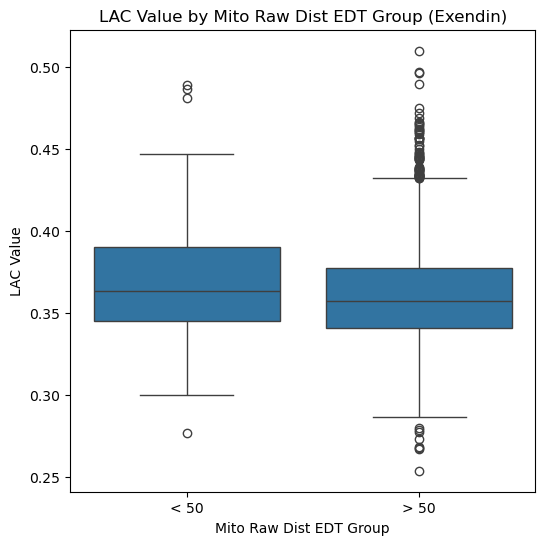

In [908]:
#Ext
rando_mitodist_ext_concat = pd.concat(
    [
        rando_mitodist_9913_1_2.assign(Cell="9913_1_2"),
        rando_mitodist_9913_5_6.assign(Cell="9913_5_6"),
        rando_mitodist_9913_3_4.assign(Cell="9913_3_4"),
        rando_mitodist_9911_2.assign(Cell="9911_2"),
        rando_mitodist_9910_4.assign(Cell="9910_4"),
    ],
    ignore_index=True
)
# Save to CSV
#rando_mitodist_ext_concat.to_csv("rando_mitodist_ext_concat.csv", index=False)


# Create distance groups
rando_mitodist_ext_concat["Distance_Group"] = pd.cut(
    rando_mitodist_ext_concat["Mito Raw Dist EDT"],
    bins=[-float("inf"), 50, float("inf")],
    labels=["< 50", "> 50"]
)
# Make boxplot
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=rando_mitodist_ext_concat,
    x="Distance_Group",
    y="LAC Value"
)
plt.xlabel("Mito Raw Dist EDT Group")
plt.ylabel("LAC Value")
plt.title("LAC Value by Mito Raw Dist EDT Group (Exendin)")

#save plot
#plt.savefig("LAC_vs_MitoDist_exendin_Boxplot.png",dpi=300,bbox_inches="tight")


plt.show()

In [874]:
# Extract groups
Exgroup_lt_50 = rando_mitodist_ext_concat.loc[
    rando_mitodist_ext_concat["Distance_Group"] == "< 50",
    "LAC Value"
].dropna()

Exgroup_gt_50 = rando_mitodist_ext_concat.loc[
    rando_mitodist_ext_concat["Distance_Group"] == "> 50",
    "LAC Value"
].dropna()

# Welch's t-test
t_stat, p_value = ttest_ind(
    Exgroup_lt_50,
    Exgroup_gt_50,
    equal_var=False
)

print("Welch's t-test results")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

Welch's t-test results
T-statistic: 2.095090447310894
P-value: 0.03842648861648614


# Local Density of Randomly Placed Granules Functions

In [244]:
#gives individual granules a label based on connectivity

def label_granules(gran_mask, connectivity=6):
    """
    Load a binary granule mask if needed and label connected components.

    Returns
    -------
    labels_img : ndarray
        0 = background, 1..N = granules
    """
    if isinstance(gran_mask, (str, bytes, os.PathLike)):
        gran_data = openmrc(gran_mask)
    else:
        gran_data = np.asarray(gran_mask)

    gran_binary = gran_data > 0

    labels_img = cc3d.connected_components(
        gran_binary.astype(np.uint8),
        connectivity=connectivity
    )

    return labels_img

#Helper function to calculate granule LAC and Diameter statistics 

def granule_lac_diameter_stats(labels_img, LAC_mrc, LACfactor):
    """
    Compute per-granule LAC statistics and geometric diameter from a labeled granule mask.

    Parameters
    ----------
    labels_img : str or ndarray
        Labeled granule image (0 = background, 1..N = granules).
    LAC_mrc : str or ndarray
        LAC volume in MRC format or already-loaded array.
    LACfactor : float
        Conversion factor used to scale LAC values and convert voxels to nm.

    Returns
    -------
    df_Ves : pandas.DataFrame
        One row per granule label with LAC and geometric measurements.
    """
    labels_img = openmrc(labels_img) if isinstance(labels_img, (str, bytes, os.PathLike)) else np.asarray(labels_img)
    openLAC_mrc = openmrc(LAC_mrc) if isinstance(LAC_mrc, (str, bytes, os.PathLike)) else np.asarray(LAC_mrc)

    resolution = (1 / LACfactor) * 1000.0

    ves_number = len(np.unique(labels_img)) - 1
    if ves_number <= 0:
        return pd.DataFrame()

    ves_centers = center_of_mass(
        np.ones_like(labels_img),
        labels_img,
        range(1, ves_number + 1)
    )
    df_Ves = pd.DataFrame(ves_centers, columns=['Centroid X', 'Centroid Y', 'Centroid Z'])
    df_Ves['Group'] = range(1, ves_number + 1)

    locations = np.argwhere(labels_img != 0)
    location_labels = labels_img[locations[:, 0], locations[:, 1], locations[:, 2]]

    locations_df = pd.DataFrame(locations, columns=['X', 'Y', 'Z'])
    locations_df['Group'] = location_labels

    lac_values = openLAC_mrc[
        locations_df['X'].values,
        locations_df['Y'].values,
        locations_df['Z'].values
    ]
    locations_df['LAC Value'] = lac_values

    grouped = locations_df.groupby('Group')['LAC Value']
    df_Ves['LAC Value'] = grouped.mean().values
    df_Ves['LAC Max'] = grouped.max().values
    df_Ves['LAC Min'] = grouped.min().values
    df_Ves['LAC Std Dev'] = grouped.std().values
    df_Ves['LAC Skew'] = grouped.skew().values
    df_Ves['LAC Kurtosis'] = grouped.apply(kurtosis).values
    df_Ves['LAC Median'] = grouped.median().values
    df_Ves['LAC 25th Quantile'] = grouped.apply(np.quantile, 0.25).values
    df_Ves['LAC 75th Quantile'] = grouped.apply(np.quantile, 0.75).values

    volumes = ndimage_sum(np.ones_like(labels_img), labels_img, range(1, ves_number + 1))
    df_Ves['Volume (um3)'] = volumes * (resolution ** 3) * ((1 / 1000) ** 3)

    x_dis = locations_df.groupby('Group')['X'].max().values - locations_df.groupby('Group')['X'].min().values
    y_dis = locations_df.groupby('Group')['Y'].max().values - locations_df.groupby('Group')['Y'].min().values
    z_dis = locations_df.groupby('Group')['Z'].max().values - locations_df.groupby('Group')['Z'].min().values
    geo_mean_dia = (x_dis * y_dis * z_dis) ** (1 / 3)

    df_Ves['Geometric Diameter (nm)'] = geo_mean_dia * resolution
    return df_Ves


#Count overlap of neighborhoods with mitochondria and cytoplasm masks. Also calculate if granule if contact or not based on local distances. 
#Uses additional function to calculate granule LAC and Diameter statistics 

def count_neighborhood_overlap(
    neigh,
    dist_maps,
    pad_slices,
    labels_img,
    LAC_mrc,
    LACfactor,
    PM_mask,
    mito_mask,
    nucl_mask,
    Gran_mask
):
    """
    Count overlaps in each granule neighborhood and add per-granule LAC + diameter stats.

    Returns
    -------
    counts_df : pandas.DataFrame
        Overlap metrics plus LAC and geometric measurements per granule.
    """
    rows = []

    pm_mask = openmrc(PM_mask) > 0 if isinstance(PM_mask, (str, bytes, os.PathLike)) else (PM_mask > 0)
    gran_mask = openmrc(Gran_mask) > 0 if isinstance(Gran_mask, (str, bytes, os.PathLike)) else (Gran_mask > 0)
    mito_mask = openmrc(mito_mask) > 0 if isinstance(mito_mask, (str, bytes, os.PathLike)) else (mito_mask > 0)
    nucl_mask = openmrc(nucl_mask) > 0 if isinstance(nucl_mask, (str, bytes, os.PathLike)) else (nucl_mask > 0)

    cyto_mask = pm_mask & ~nucl_mask

    for lab, coords in neigh.items():
        if coords is None or len(coords) == 0:
            rows.append({
                "label": lab,
                "cyto_voxels": 0,
                "mito_voxels": 0,
                "mito_over_cyto_voxels": np.nan,
                "mito_within_50nm": 0,
                "mito_within_50nm_flag": 0
            })
            continue

        z, y, x = coords[:, 0], coords[:, 1], coords[:, 2]
        cyto_hits = cyto_mask[z, y, x]
        mito_hits = mito_mask[z, y, x]

        dist_nm = dist_maps[lab]
        pad_sl = pad_slices[lab]
        local_mito = mito_mask[pad_sl]
        mito_within_50 = local_mito & (dist_nm < 50)

        rows.append({
            "label": lab,
            "cyto_voxels": int(cyto_hits.sum()),
            "mito_voxels": int(mito_hits.sum()),
            "mito_over_cyto_voxels": float(mito_hits.sum() / cyto_hits.sum()) if cyto_hits.sum() > 0 else np.nan,
            "mito_within_50nm": int(mito_within_50.sum()),
            "mito_within_50nm_flag": 1 if mito_within_50.any() else 0
        })

    counts_df = pd.DataFrame(rows)

    lac_dia_df = granule_lac_diameter_stats(labels_img, LAC_mrc, LACfactor)
    if not lac_dia_df.empty:
        counts_df = counts_df.merge(
            lac_dia_df,
            left_on="label",
            right_on="Group",
            how="left"
        ).drop(columns=["Group"])

    return counts_df

In [217]:
#Generate local granule neighborhoods based on threshold
#for random placed already labeled granules

def rando_granule_neighborhood_overlap(
    array_placeddf,
    rando_mask_label,
    fileslist,
    LACfactor,
    distance_nm=500,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
):
    """
    Run rando_granule_neighborhoods_local + count_neighborhood_overlap in one step.
    """
    if len(fileslist) < 5:
        raise ValueError(
            "fileslist must contain [PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc]."
        )

    PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc = fileslist[:5]

    neigh, dist_maps, pad_slices, labels_img = rando_granule_neighborhoods_local(
        rando_mask_label,
        LACfactor=LACfactor,
        distance_nm=distance_nm,
        return_coords=True,
        return_dist_maps=True,
        return_pad_slices=True,
    )

    counts_df = count_neighborhood_overlap(
        neigh=neigh,
        dist_maps=dist_maps,
        pad_slices=pad_slices,
        labels_img=labels_img,
        LAC_mrc=array_placeddf,
        LACfactor=LACfactor,
        PM_mask=PM_mask,
        mito_mask=mito_mask,
        nucl_mask=nucl_mask,
        Gran_mask=Gran_mask,
    )

    outputs = [counts_df]
    if return_coords:
        outputs.append(neigh)
    if return_dist_maps:
        outputs.append(dist_maps)
    if return_pad_slices:
        outputs.append(pad_slices)
    outputs.append(labels_img)

    return tuple(outputs)


In [214]:
#Combined Function, for random placed already labeled granules
def rando_granule_neighborhood_overlap(
    array_placeddf,
    rando_mask_label,
    fileslist,
    LACfactor,
    distance_nm=500,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
):
    """
    Run granule_neighborhoods_local + count_neighborhood_overlap in one step.

    Parameters
    ----------
    fileslist : sequence
        [PM_mask, mito_mask, nucl_mask, Gran_mask]
    LACfactor : float
        LAC factor used to convert voxels to nm.
    distance_nm : float
        Neighborhood distance threshold in nm.
    return_coords, return_dist_maps, return_pad_slices : bool
        Match the underlying granule_neighborhoods_local return behavior.
        Note: count_neighborhood_overlap requires coords, dist_maps, and pad_slices,
        so they are computed internally regardless of these flags.

    Returns
    -------
    If return_coords=True, return_dist_maps=True, return_pad_slices=True:
        counts_df, neigh, dist_maps, pad_slices, labels_img
    Otherwise:
        counts_df plus whichever of neigh / dist_maps / pad_slices were requested,
        followed by labels_img.
    """
    if len(fileslist) < 5:
        raise ValueError("fileslist must contain [PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc].")

    PM_mask, mito_mask, nucl_mask, Gran_mask, LAC_mrc  = fileslist[:5]

    # Always compute all intermediates needed for counting
    neigh, dist_maps, pad_slices, labels_img = rando_granule_neighborhoods_local(
        rando_mask_label,
        LACfactor=LACfactor,
        distance_nm=distance_nm,
        return_coords=True,
        return_dist_maps=True,
        return_pad_slices=True,
    )

    counts_df = count_neighborhood_overlap(
        neigh,
        dist_maps,
        pad_slices,
        labels_img,
        LAC_mrc = array_placeddf,
        LACfactor = LACfactor,
        PM_mask=PM_mask,
        mito_mask=mito_mask,
        nucl_mask=nucl_mask,
        Gran_mask=Gran_mask,
    )

    outputs = [counts_df]

    if return_coords:
        outputs.append(neigh)
    if return_dist_maps:
        outputs.append(dist_maps)
    if return_pad_slices:
        outputs.append(pad_slices)

    outputs.append(labels_img)

    return tuple(outputs)

# Local Density of Randomly Placed Granules Analyses

In [305]:
def array_fromplaceddf(
    file_list,
    placed_df_new,
    x_max=None,
    y_max=None,
    z_max=None,
):
    # Load PM and mito masks
    arr_PM = openmrc(file_list[0])

    # Infer shape from PM mask if not provided
    if x_max is None or y_max is None or z_max is None:
        z_max, y_max, x_max = arr_PM.shape

    # Create 3D volume
    volume_randomplace = np.zeros((x_max, y_max, z_max))

    volume_randomplace[
        placed_df_new["Z"].to_numpy(),
        placed_df_new["Y"].to_numpy(),
        placed_df_new["X"].to_numpy()
    ] = placed_df_new["Group"].to_numpy()

    #"New" LAC mrc based on previous one 
    randonew_lac_mrc = np.zeros((z_max, y_max, x_max))
    
    randonew_lac_mrc[
        placed_df_new["Z"].to_numpy(),
        placed_df_new["Y"].to_numpy(),
        placed_df_new["X"].to_numpy()
    ] = placed_df_new["LAC Value"].to_numpy()

    return randonew_lac_mrc

In [186]:
count_df_concat = pd.read_pickle("count_df_concat.pkl")
count_df_concat

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell
0,1,38771,1030,0.026566,0,0,73.237500,263.700000,252.012500,0.307060,...,0.256875,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002,1537_19
1,2,56410,1297,0.022992,0,0,76.850877,383.903509,215.754386,0.300995,...,0.254046,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426,1537_19
2,3,52927,4856,0.091749,0,0,75.581818,384.818182,271.072727,0.328830,...,0.283468,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775,1537_19
3,4,62511,3818,0.061077,0,0,78.165049,294.111650,236.757282,0.343917,...,0.298872,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457,1537_19
4,5,56269,3363,0.059766,0,0,77.333333,319.015873,244.650794,0.321087,...,0.265886,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591,1537_19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6018,1373,43389,762,0.017562,0,0,370.096774,299.709677,231.645161,0.305471,...,0.283239,0.014765,0.667135,-0.312184,0.299941,0.295175,0.316503,0.001067,85.255088,6_17_19
6019,1374,49082,301,0.006133,0,0,370.990654,412.355140,170.691589,0.308251,...,0.280399,0.015837,0.397342,-0.696306,0.307293,0.295381,0.318948,0.003684,187.670731,6_17_19
6020,1375,41463,0,0.000000,0,0,372.258621,311.224138,236.603448,0.275697,...,0.250028,0.018281,0.534131,-0.496250,0.272935,0.258691,0.287270,0.001997,150.995082,6_17_19
6021,1376,43179,0,0.000000,0,0,372.051724,328.758621,232.379310,0.311265,...,0.276166,0.018096,0.251138,-0.541309,0.310131,0.294641,0.322342,0.001997,140.171418,6_17_19


In [307]:
array_placed_df_1537_16_18 = array_fromplaceddf(NS_1537_16_18_files, placed_df_1537_16_18)
array_placed_df_1537_19 = array_fromplaceddf(NS_1537_19_files, placed_df_1537_19)
array_placed_df_6_17_19 = array_fromplaceddf(NS_6_17_19_files, placed_df_6_17_19)
array_placed_df_6_5 = array_fromplaceddf(NS_6_5_files, placed_df_6_5)
array_placed_df_7_22 = array_fromplaceddf(NS_7_22_files, placed_df_7_22)
array_placed_df_7_8_9 = array_fromplaceddf(NS_7_8_9_files, placed_df_7_8_9)


In [356]:
#NS Analysis
threshold_nm = 100

#1537_19
rando_counts_df_1537_19, rando_neigh_1537_19, rando_dist_maps_1537_19, rando_pad_slices_1537_19, rando_labels_img_1537_19 = rando_granule_neighborhood_overlap(
    array_placed_df_1537_19,
    volume_randomplace_1537_19,
    NS_1537_19_files,
    LACfactor=LACfactordict["1537_19"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#7_22
rando_counts_df_7_22, rando_neigh_7_22, rando_dist_maps_7_22, rando_pad_slices_7_22, rando_labels_img_7_22 = rando_granule_neighborhood_overlap(
    array_placed_df_7_22,
    volume_randomplace_7_22,
    NS_7_22_files,
    LACfactor=LACfactordict["7_22"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#6_5
rando_counts_df_6_5, rando_neigh_6_5, rando_dist_maps_6_5, rando_pad_slices_6_5, rando_labels_img_6_5 = rando_granule_neighborhood_overlap(
    array_placed_df_6_5,
    volume_randomplace_6_5,
    NS_6_5_files,
    LACfactor=LACfactordict["6_5"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#1537_16_18
rando_counts_df_1537_16_18, rando_neigh_1537_16_18, rando_dist_maps_1537_16_18, rando_pad_slices_1537_16_18, rando_labels_img_1537_16_18 = rando_granule_neighborhood_overlap(
    array_placed_df_1537_16_18,
    volume_randomplace_1537_16_18,
    NS_1537_16_18_files,
    LACfactor=LACfactordict["1537_16-18"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#7_8_9
rando_counts_df_7_8_9, rando_neigh_7_8_9, rando_dist_maps_7_8_9, rando_pad_slices_7_8_9, rando_labels_img_7_8_9 = rando_granule_neighborhood_overlap(
    array_placed_df_7_8_9,
    volume_randomplace_7_8_9,
    NS_7_8_9_files,
    LACfactor=LACfactordict["7_8=9"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

#6_17_19
rando_counts_df_6_17_19, rando_neigh_6_17_19, rando_dist_maps_6_17_19, rando_pad_slices_6_17_19, rando_labels_img_6_17_19 = rando_granule_neighborhood_overlap(
    array_placed_df_6_17_19,
    volume_randomplace_6_17_19,
    NS_6_17_19_files,
    LACfactor=LACfactordict["6_17-19"],
    distance_nm=threshold_nm,
    return_coords=True,
    return_dist_maps=True,
    return_pad_slices=True,
)

C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\scipy\ndimage\_measurements.py:1542: RuntimeWarning: invalid value encountered in divide
  results = [sum(input * grids[dir].astype(float), labels, index) / normalizer
C:\Users\kchang42\AppData\Local\anaconda3\Lib\site-packages\mrcfile\mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), 

In [357]:
rando_count_df_concat = pd.concat(
    [
        rando_counts_df_1537_19.assign(Cell="1537_19"),
        rando_counts_df_7_22.assign(Cell="7_22"),
        rando_counts_df_6_5.assign(Cell="6_5"),
        rando_counts_df_1537_16_18.assign(Cell="1537_16_18"),
        rando_counts_df_7_8_9.assign(Cell="7_8_9"),
        rando_counts_df_6_17_19.assign(Cell="6_17_19"),
    ],
    ignore_index=True
)

In [358]:
#where above 0 mito ratio. Keep only mito/cytoplasm ratio, as well as if in contact or not
subset_rando_count_concat = rando_count_df_concat[rando_count_df_concat["mito_over_cyto_voxels"] > 0]
subset_rando_count_concat

,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Min,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell
20,21,834,65,0.077938,6,1,260.125000,377.486111,225.583333,0.276899,...,0.228869,0.018853,-0.228391,-0.074149,0.277623,0.265589,0.288873,0.001945,131.398714,1537_19
68,69,1065,12,0.011268,0,0,155.352601,116.491329,332.341040,0.343376,...,0.293148,0.022984,0.206889,-0.169345,0.343668,0.327694,0.356683,0.004672,178.335492,1537_19
133,134,1187,99,0.083404,10,1,353.614458,370.753012,157.469880,0.335773,...,0.293270,0.017203,0.077982,-0.405866,0.334852,0.322929,0.347996,0.004483,208.582457,1537_19
153,154,1224,76,0.062092,0,0,171.698413,394.650794,385.862434,0.318610,...,0.256556,0.022128,0.059554,0.354448,0.317383,0.304997,0.331894,0.005105,199.501943,1537_19
166,167,638,60,0.094044,4,1,241.770833,305.187500,94.104167,0.294109,...,0.252585,0.020047,-0.067059,-0.820976,0.294510,0.278301,0.311037,0.001296,129.279009,1537_19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5905,1310,621,70,0.112721,9,1,339.098361,327.770492,304.377049,0.277151,...,0.246261,0.014018,-0.139829,-0.379382,0.276848,0.266506,0.288055,0.002100,150.995082,6_17_19
5913,1318,1640,76,0.046341,11,1,304.388060,373.977612,82.160448,0.262895,...,0.225916,0.016339,0.318773,-0.052247,0.262460,0.251225,0.273413,0.009226,318.215566,6_17_19
5933,1338,647,71,0.109737,11,1,107.242857,399.157143,142.571429,0.275594,...,0.253429,0.010051,0.116554,-0.394072,0.275672,0.269041,0.281622,0.002410,140.171418,6_17_19
5943,1348,969,24,0.024768,1,1,105.582609,371.686957,325.678261,0.310343,...,0.285982,0.012596,0.263420,-0.341920,0.309539,0.301340,0.318356,0.003959,205.476890,6_17_19


In [359]:
# Create 10 bins
subset_rando_count_concat["bin"] = pd.cut(
    subset_rando_count_concat["mito_over_cyto_voxels"],
    bins=30
)

# Calculate percentage of 1s in each bin
randobin_summary_concat = (
    subset_rando_count_concat
    .groupby("bin")["mito_within_50nm_flag"]
    .agg(
        total="count",
        positives="sum"
    )
    .assign(
        percent_ones=lambda x: 100 * x["positives"] / x["total"]
    )
    .reset_index()
)

print(randobin_summary_concat)

                    bin  total  positives  percent_ones
0   (0.000305, 0.00841]     77          0      0.000000
1     (0.00841, 0.0163]     31          0      0.000000
2      (0.0163, 0.0241]     29          2      6.896552
3       (0.0241, 0.032]     27          7     25.925926
4       (0.032, 0.0399]     22          9     40.909091
5      (0.0399, 0.0477]     23         13     56.521739
6      (0.0477, 0.0556]     15         13     86.666667
7      (0.0556, 0.0635]     11          8     72.727273
8      (0.0635, 0.0713]      9          7     77.777778
9      (0.0713, 0.0792]      7          7    100.000000
10     (0.0792, 0.0871]      9          8     88.888889
11     (0.0871, 0.0949]      9          9    100.000000
12      (0.0949, 0.103]      7          7    100.000000
13       (0.103, 0.111]      9          9    100.000000
14       (0.111, 0.119]      7          7    100.000000
15       (0.119, 0.126]      3          3    100.000000
16       (0.126, 0.134]      5          5    100

C:\Users\kchang42\AppData\Local\Temp\ipykernel_49112\998661739.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_rando_count_concat["bin"] = pd.cut(
C:\Users\kchang42\AppData\Local\Temp\ipykernel_49112\998661739.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")["mito_within_50nm_flag"]


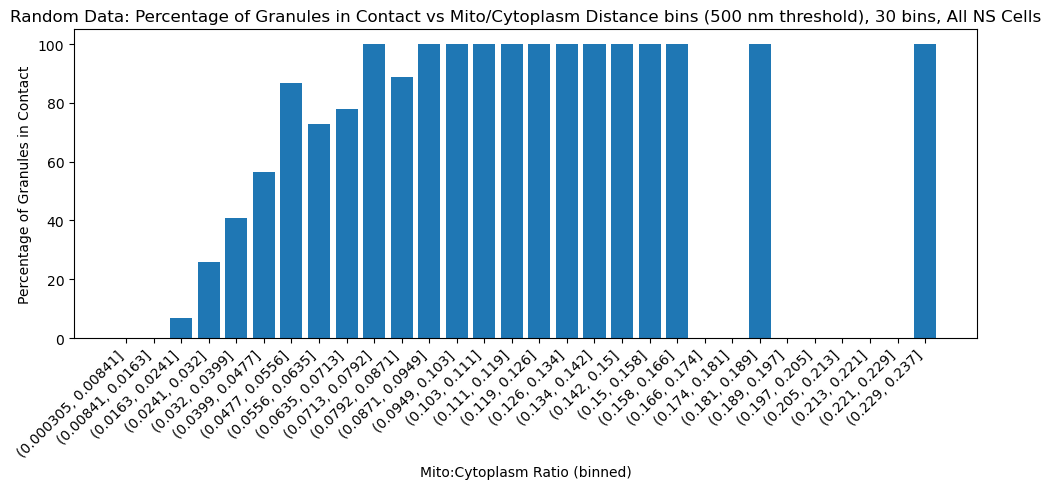

In [360]:
# Convert interval bins to strings for plotting
randobin_labels_concat = randobin_summary_concat["bin"].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    randobin_labels_concat,
    randobin_summary_concat["percent_ones"]
)

ax.set_xlabel("Mito:Cytoplasm Ratio (binned)")
ax.set_ylabel("Percentage of Granules in Contact")
ax.set_title("Random Data: Percentage of Granules in Contact vs Mito/Cytoplasm Distance bins (500 nm threshold), 30 bins, All NS Cells")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig("MitoDensity_contact_1000.png",dpi=300,bbox_inches="tight")

plt.show()

In [325]:
Mito750thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/750nm_Combo_rando_real_mitodens.csv")
Mito500thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/500nm_Combo_rando_real_mitodens.csv")
Mito250thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/250nm_Combo_rando_real_mitodens.csv")
Mito100thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/100nm_Combo_rando_real_mitodens.csv")

Mito750thresh_exp = Mito750thresh[Mito750thresh["Source"] == "Experimental"].copy()
Mito500thresh_exp = Mito500thresh[Mito500thresh["Source"] == "Experimental"].copy()
Mito250thresh_exp = Mito250thresh[Mito250thresh["Source"] == "Experimental"].copy()
Mito100thresh_exp = Mito100thresh[Mito100thresh["Source"] == "Experimental"].copy()

In [362]:
#Both real and randomly placed data
Combo_rando_real_mitodens_100 =  pd.concat(
    [
        #count_df_concat.assign(Source="Experimental"),
        Mito100thresh_exp,
        rando_count_df_concat.assign(Source="Random Placement"),
    ],
    ignore_index=True
)

#Combo_rando_real_mitodens_100.to_csv("NEW_100nm_Combo_rando_real_mitodens.csv",index=False)

Combo_rando_real_mitodens_100


,label,cyto_voxels,mito_voxels,mito_over_cyto_voxels,mito_within_50nm,mito_within_50nm_flag,Centroid X,Centroid Y,Centroid Z,LAC Value,...,LAC Std Dev,LAC Skew,LAC Kurtosis,LAC Median,LAC 25th Quantile,LAC 75th Quantile,Volume (um3),Geometric Diameter (nm),Cell,Source
0,1,451,0,0.000000,0,0,73.237500,263.700000,252.012500,0.307060,...,0.022202,-0.183304,-0.761685,0.309746,0.288654,0.323563,0.002161,150.015002,1537_19,Experimental
1,2,943,0,0.000000,0,0,76.850877,383.903509,215.754386,0.300995,...,0.022650,0.144516,-0.389380,0.300367,0.285002,0.315677,0.003079,169.403426,1537_19,Experimental
2,3,680,0,0.000000,0,0,75.581818,384.818182,271.072727,0.328830,...,0.019944,-0.112387,-0.285448,0.327869,0.318648,0.343884,0.001485,117.457775,1537_19,Experimental
3,4,1277,0,0.000000,0,0,78.165049,294.111650,236.757282,0.343917,...,0.021490,0.751627,1.180491,0.341721,0.329744,0.357138,0.005564,208.582457,1537_19,Experimental
4,5,706,0,0.000000,0,0,77.333333,319.015873,244.650794,0.321087,...,0.021179,0.025024,-0.163167,0.320079,0.304747,0.336763,0.001702,139.261591,1537_19,Experimental
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11991,1373,428,0,0.000000,0,0,302.096774,167.709677,174.645161,0.305471,...,0.014765,0.667135,-0.312184,0.299941,0.295175,0.316503,0.001067,85.255088,6_17_19,Random Placement
11992,1374,854,0,0.000000,0,0,63.990654,398.355140,136.691589,0.308251,...,0.015837,0.397342,-0.696305,0.307293,0.295381,0.318948,0.003684,187.670731,6_17_19,Random Placement
11993,1375,613,18,0.029364,0,0,307.258621,190.224138,154.603448,0.275697,...,0.018281,0.534131,-0.496250,0.272935,0.258691,0.287270,0.001997,150.995082,6_17_19,Random Placement
11994,1376,598,0,0.000000,0,0,76.051724,450.758621,175.379310,0.311265,...,0.018096,0.251138,-0.541309,0.310131,0.294641,0.322342,0.001997,140.171418,6_17_19,Random Placement


In [335]:
# Create 10 bins
Combo_rando_real_mitodens["bin"] = pd.cut(
    Combo_rando_real_mitodens["mito_over_cyto_voxels"],
    bins=30
)

# Calculate percentage of 1s in each bin
combobin_summary_concat = (
    Combo_rando_real_mitodens
    .groupby("bin")["mito_within_50nm_flag"]
    .agg(
        total="count",
        positives="sum"
    )
    .assign(
        percent_ones=lambda x: 100 * x["positives"] / x["total"]
    )
    .reset_index()
)

print(combobin_summary_concat)

                     bin  total  positives  percent_ones
0   (-0.000278, 0.00927]   5285          0      0.000000
1      (0.00927, 0.0185]   1113          2      0.179695
2       (0.0185, 0.0278]    954          7      0.733753
3       (0.0278, 0.0371]    831          7      0.842359
4       (0.0371, 0.0464]    749         22      2.937250
5       (0.0464, 0.0556]    678         29      4.277286
6       (0.0556, 0.0649]    549         30      5.464481
7       (0.0649, 0.0742]    437         27      6.178490
8       (0.0742, 0.0835]    343         27      7.871720
9       (0.0835, 0.0927]    253         29     11.462451
10       (0.0927, 0.102]    219         21      9.589041
11        (0.102, 0.111]    151         20     13.245033
12        (0.111, 0.121]    108         14     12.962963
13         (0.121, 0.13]     90         16     17.777778
14         (0.13, 0.139]     71         14     19.718310
15        (0.139, 0.148]     45         15     33.333333
16        (0.148, 0.158]     38

C:\Users\kchang42\AppData\Local\Temp\ipykernel_49112\2002457661.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")["mito_within_50nm_flag"]


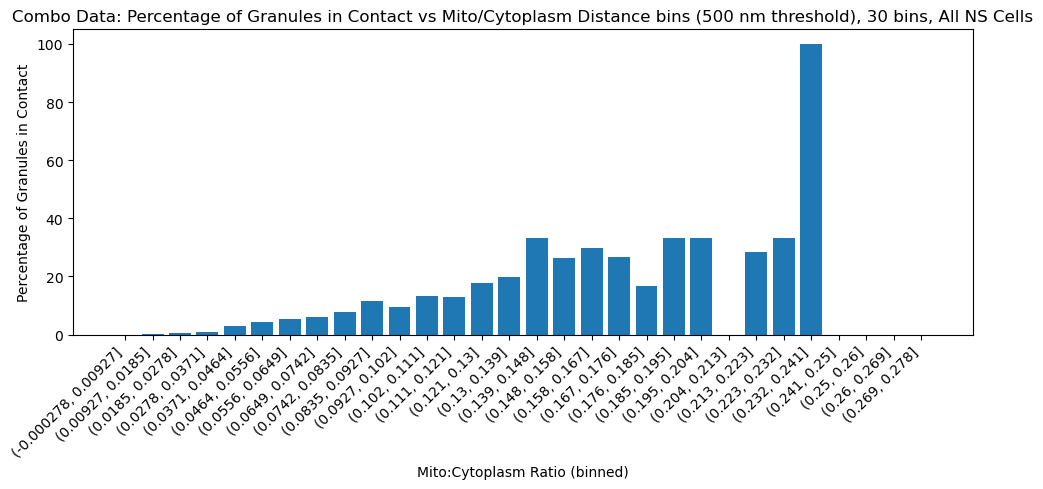

In [336]:
# Convert interval bins to strings for plotting
combo_labels_concat = combobin_summary_concat["bin"].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    combo_labels_concat,
    combobin_summary_concat["percent_ones"]
)

ax.set_xlabel("Mito:Cytoplasm Ratio (binned)")
ax.set_ylabel("Percentage of Granules in Contact")
ax.set_title("Combo Data: Percentage of Granules in Contact vs Mito/Cytoplasm Distance bins (500 nm threshold), 30 bins, All NS Cells")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig("MitoDensity_contact_1000.png",dpi=300,bbox_inches="tight")

plt.show()

In [337]:
#Plotting seperately 

In [338]:
# Calculate percentage of 1s in each bin AND Source
combobin_summary_concat = (
    Combo_rando_real_mitodens
    .groupby(["Source", "bin"], observed=True)["mito_within_50nm_flag"]
    .agg(
        total="count",
        positives="sum"
    )
    .assign(
        percent_ones=lambda x: 100 * x["positives"] / x["total"]
    )
    .reset_index()
)

print(combobin_summary_concat)

              Source                   bin  total  positives  percent_ones
0       Experimental  (-0.000278, 0.00927]   2522          0      0.000000
1       Experimental     (0.00927, 0.0185]    557          2      0.359066
2       Experimental      (0.0185, 0.0278]    496          5      1.008065
3       Experimental      (0.0278, 0.0371]    416          6      1.442308
4       Experimental      (0.0371, 0.0464]    382          8      2.094241
5       Experimental      (0.0464, 0.0556]    321         15      4.672897
6       Experimental      (0.0556, 0.0649]    298         19      6.375839
7       Experimental      (0.0649, 0.0742]    221         15      6.787330
8       Experimental      (0.0742, 0.0835]    176         12      6.818182
9       Experimental      (0.0835, 0.0927]    141         16     11.347518
10      Experimental       (0.0927, 0.102]    129         17     13.178295
11      Experimental        (0.102, 0.111]     91         11     12.087912
12      Experimental     

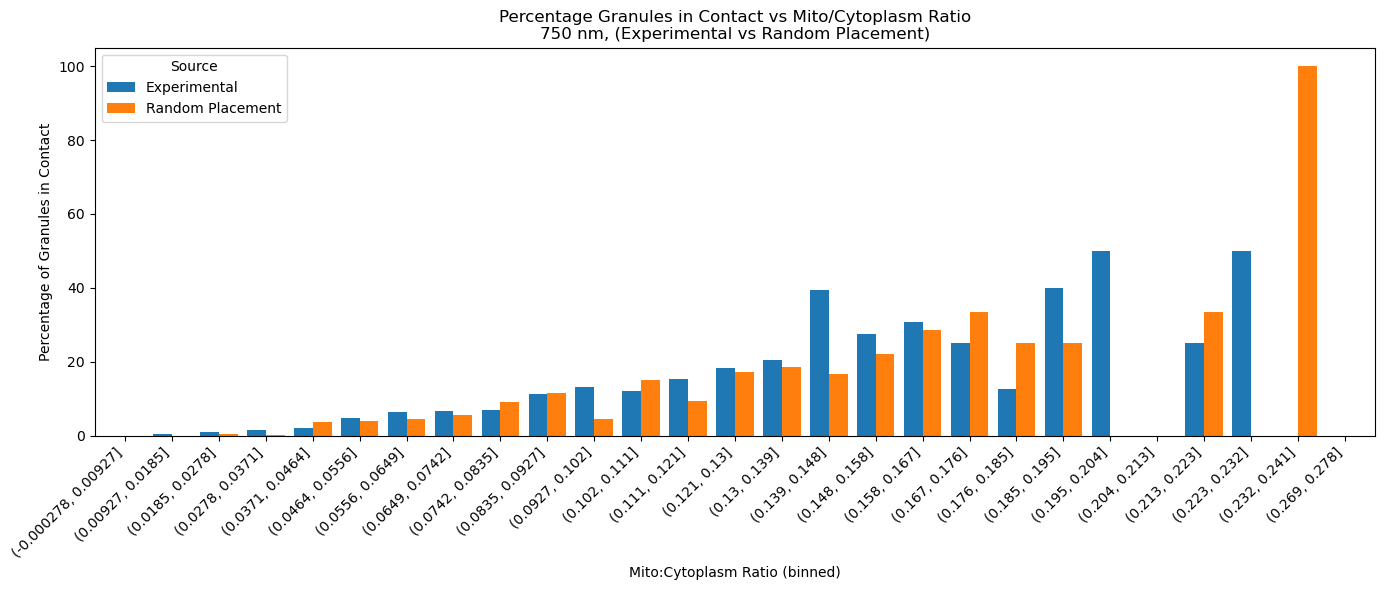

In [339]:
# Convert bins to strings for plotting
combobin_summary_concat["bin_str"] = (
    combobin_summary_concat["bin"].astype(str)
)

# Pivot so Experimental and Random Placement become separate columns
plot_df = combobin_summary_concat.pivot(
    index="bin_str",
    columns="Source",
    values="percent_ones"
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

ax.set_xlabel("Mito:Cytoplasm Ratio (binned)")
ax.set_ylabel("Percentage of Granules in Contact")
ax.set_title(
    "Percentage Granules in Contact vs Mito/Cytoplasm Ratio\n"
    "750 nm, (Experimental vs Random Placement)"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig("Combo_MitoDensity_contact_750.png", dpi=300, bbox_inches="tight")

plt.show()

In [80]:
#Scatterplots of Mito Density vs LAC and Diameter

In [108]:
def plot_mito_scatterplots(
    df,
    title,
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source",
    figsize=(7, 5),
    alpha=0.75,
    s=25,
    add_regression=True,
):
    """
    Create two scatterplots:
      1) x_col vs y1_col
      2) x_col vs y2_col

    Points are colored by source_col and optionally include
    separate linear regression lines for each source.

    Parameters
    ----------
    df : pandas.DataFrame
    title : str
        Base title for plots.
    x_col : str
    y1_col : str
    y2_col : str
    source_col : str
    figsize : tuple
    alpha : float
    s : int
    add_regression : bool
    """

    needed = [x_col, y1_col, y2_col, source_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    sources = list(df[source_col].dropna().unique())

    cmap = plt.get_cmap("tab10")
    colors = {src: cmap(i % 10) for i, src in enumerate(sources)}

    def make_plot(y_col, subtitle):

        plt.figure(figsize=figsize)

        for src in sources:

            sub = df[df[source_col] == src].copy()

            x = sub[x_col].values
            y = sub[y_col].values

            valid = ~(np.isnan(x) | np.isnan(y))
            x = x[valid]
            y = y[valid]

            plt.scatter(
                x,
                y,
                label=str(src),
                color=colors[src],
                alpha=alpha,
                s=s
            )

            if add_regression and len(x) > 1:

                slope, intercept = np.polyfit(x, y, 1)

                x_fit = np.linspace(x.min(), x.max(), 100)
                y_fit = slope * x_fit + intercept

                plt.plot(
                    x_fit,
                    y_fit,
                    color=colors[src],
                    linewidth=2
                )

        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{title}\n{subtitle}")
        plt.legend(title=source_col)
        plt.tight_layout()
        plt.show()

    make_plot(y1_col, f"{x_col} vs {y1_col}")
    make_plot(y2_col, f"{x_col} vs {y2_col}")

In [111]:
def plot_mito_scatterplots_save(
    df,
    title,
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source",
    save_prefix=None,
    figsize=(7, 5),
    alpha=0.75,
    s=25,
):
    """
    Make two scatterplots with linear regression lines by source.
    Saves figures if save_prefix is provided.
    Returns the two figure objects.
    """

    needed = [x_col, y1_col, y2_col, source_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    sources = [s for s in df[source_col].dropna().unique()]
    cmap = plt.get_cmap("tab10")
    colors = {src: cmap(i % 10) for i, src in enumerate(sources)}

    def make_plot(y_col, subtitle, filename=None):
        fig, ax = plt.subplots(figsize=figsize)

        for src in sources:
            sub = df[df[source_col] == src].copy()

            x = sub[x_col].to_numpy()
            y = sub[y_col].to_numpy()

            # Keep only finite values
            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            if len(x) == 0:
                continue

            ax.scatter(
                x, y,
                label=str(src),
                color=colors[src],
                alpha=alpha,
                s=s
            )

            # Regression only if it is numerically safe
            if len(x) >= 2 and np.unique(x).size >= 2:
                try:
                    slope, intercept = np.polyfit(x, y, 1)
                    xfit = np.linspace(np.min(x), np.max(x), 100)
                    yfit = slope * xfit + intercept
                    ax.plot(xfit, yfit, color=colors[src], linewidth=2)
                except np.linalg.LinAlgError:
                    # Skip regression line for this group if fit fails
                    pass

        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{title}\n{subtitle}")
        ax.legend(title=source_col)
        fig.tight_layout()

        if filename:
            fig.savefig(filename, dpi=300, bbox_inches="tight")

        return fig

    fig1 = make_plot(
        y1_col,
        f"{x_col} vs {y1_col}",
        None if save_prefix is None else f"{save_prefix}_LAC.png"
    )

    fig2 = make_plot(
        y2_col,
        f"{x_col} vs {y2_col}",
        None if save_prefix is None else f"{save_prefix}_Diameter.png"
    )

    return fig1, fig2

In [88]:
Mito750thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/750nm_Combo_rando_real_mitodens.csv")
Mito500thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/500nm_Combo_rando_real_mitodens.csv")
Mito250thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/250nm_Combo_rando_real_mitodens.csv")
Mito100thresh = pd.read_csv("D:/Downloads/MitoRandomAnalysis/100nm_Combo_rando_real_mitodens.csv")


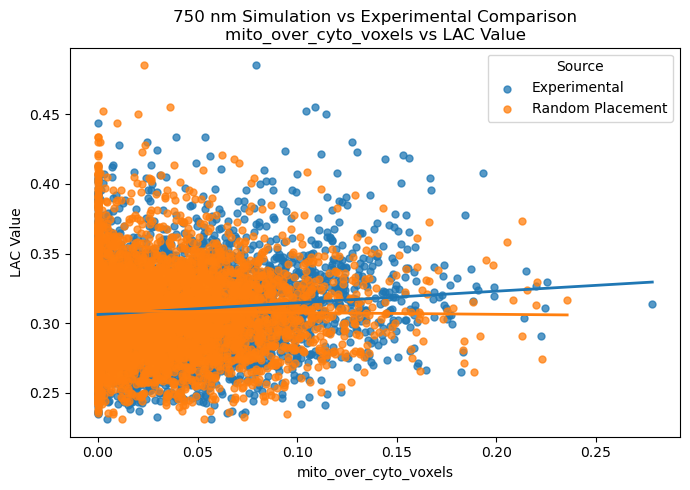

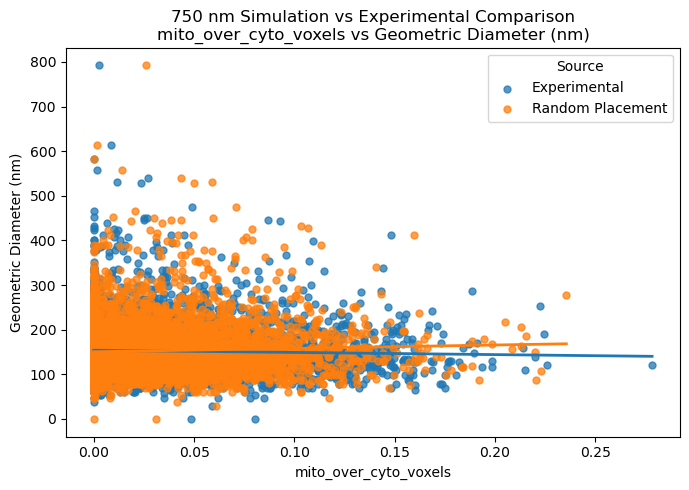

In [334]:
#Combo_rando_real_mitodens

plot750 = plot_mito_scatterplots(
    Combo_rando_real_mitodens_750,
    title="750 nm Simulation vs Experimental Comparison",
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source"
)
plot750

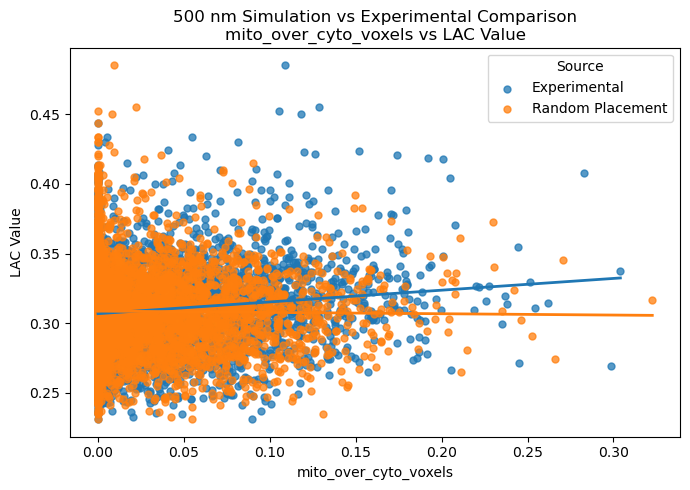

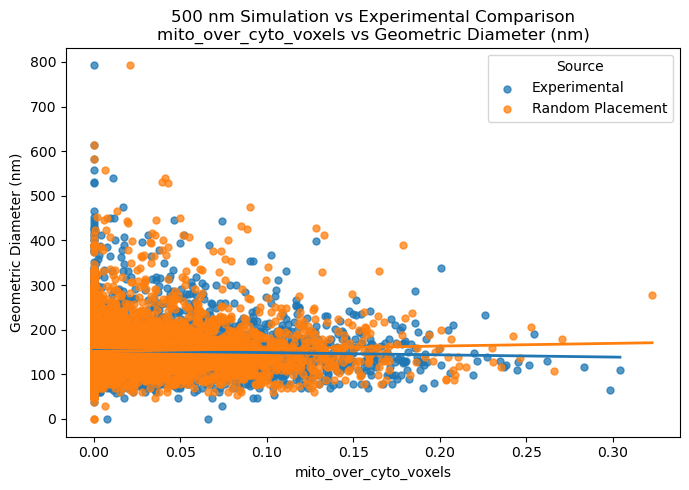

In [347]:
plot500 = plot_mito_scatterplots(
    Combo_rando_real_mitodens_500,
    title="500 nm Simulation vs Experimental Comparison",
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source"
)

plot500



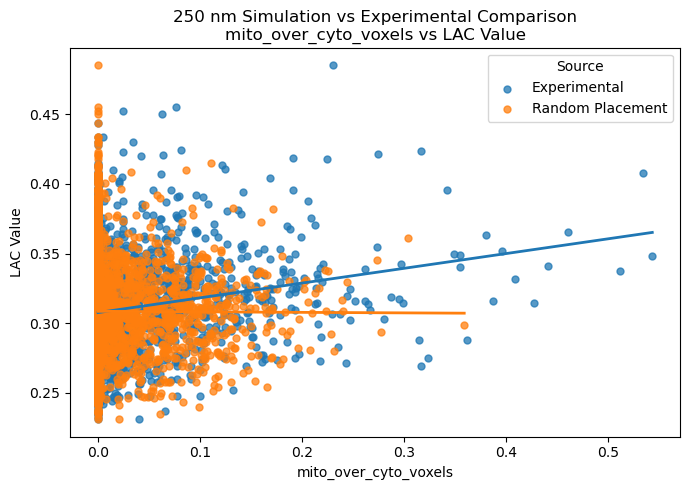

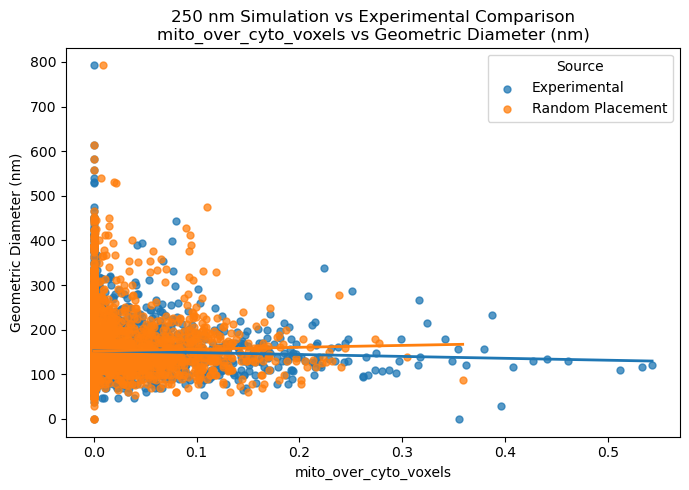

In [355]:
plot250 = plot_mito_scatterplots(
    Combo_rando_real_mitodens_250,
    title="250 nm Simulation vs Experimental Comparison",
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source"
)
plot250

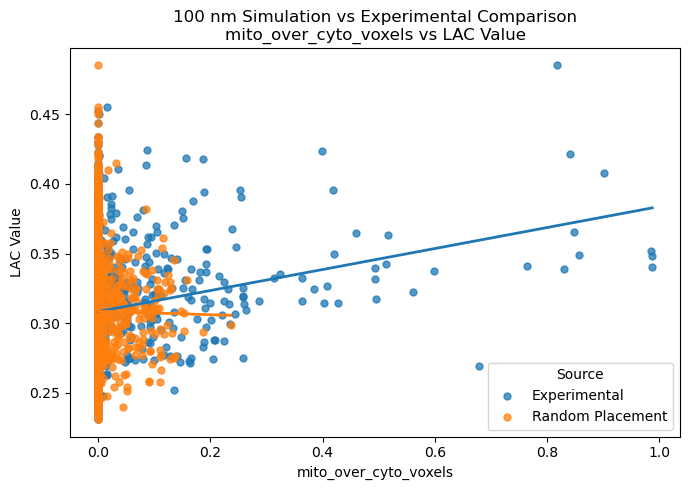

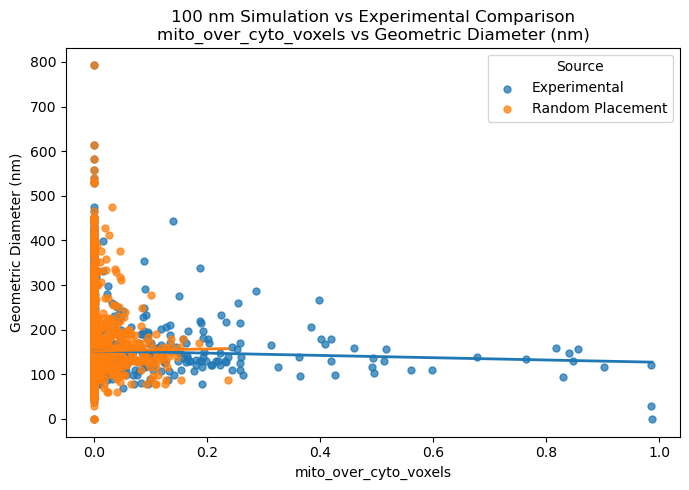

In [364]:
plot100 = plot_mito_scatterplots(
    Combo_rando_real_mitodens_100,
    title="100 nm Simulation vs Experimental Comparison",
    x_col="mito_over_cyto_voxels",
    y1_col="LAC Value",
    y2_col="Geometric Diameter (nm)",
    source_col="Source"
)
plot100